# Sistema 6G – Processamento de Sinais IQ e Pré-Distorção Digital com VARMAX

## Objetivo

Este notebook tem como objetivo:

- Entender como o problema de pré-distorção digital pode ser modelado como séries temporais
- Implementar um modelo VARMAX
- Analisar dados reais de amplificador de potência (PA)
- Avaliar desempenho do modelo

---

## Contexto

Em sistemas de comunicação (5G/6G), o amplificador de potência (PA):

- Amplifica o sinal antes da transmissão
- Introduz **não linearidades**, principalmente próximo da saturação

Essas não linearidades causam:

- Distorção do sinal
- Interferência em canais adjacentes
- Perda de eficiência energética

---

## Solução: Pré-Distorção Digital (DPD)

A ideia é:

1. Modelar o comportamento do PA
2. Aplicar uma distorção inversa no sinal de entrada
3. O PA "corrige" essa distorção → saída linearizada

---

## Por que Séries Temporais?

O PA possui **memória**:

- Efeitos térmicos
- Capacitâncias
- Histerese

Ou seja:

> A saída atual depende de entradas passadas

*Isso caracteriza um problema de **séries temporais***


## Bloco 1 - Importações e Carga de Dados
Células 00 .. 03 - Introdução
### Célula 00 - Instalação explicita da versão específica do xlrd.
*<span style="color:grey">O '!' no Jupyter executa o comando no terminal do sistema operacional, não no Python.</span>*

In [2]:
!pip install xlrd==2.0.1

Error processing line 1 of /home/isaac-kosloski/anaconda3/envs/varmax/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### Célula 01 - Importações de bibliotecas principais

In [3]:
import pandas as pd                                 # Manipulação de tableas (DataFrames)
import numpy as np                                  # Cálculo numérico vetorial
import matplotlib.pyplot as plt                     # Visualização de gráficos
import seaborn as sns                               # Gráficos estatísticos
from sklearn.linear_model import LinearRegression   # Regressão Linear

### Célula 02 - Ajuste de parâmetros visuais

*<span style="color:grey">A customização de parâmetros visuais se da por meio da biblioteca matplotlib, o padrão e também utilizando o objeto **rcParams** do módulo pylab. Significa "Runtime Configuration Parameters".</span>*

In [4]:
from matplotlib.pylab import rcParams               # Customização de parâmetros visuais
rcParams['figure.figsize'] = 15, 6                  # Width = 15 inches; Height = 6 inches
plt.style.use('dark_background')                    # Estilo de background escuro, para os gráficos

### Célula 03 - Carregamento dos dados iniciais

> Para este projeto de telecomunicações, espera-se por dados IQ que provem de instrumentos de medida que exportam em Excel.


In [5]:
from pathlib import Path                            # Construção de Path
data_file = "dadosIniciais.xlsx"                    # Define o nome do arquivo com o DataFrame em Excel

DATA_PATH = Path.cwd() / data_file                  # Constrói o path absoluto para o arquivo de dados

data = pd.read_excel(DATA_PATH, engine="openpyxl")  # Lê o dataframe com o openpyxl, para arquivos .xlsx
print(f"Shape: {data.shape}")                       # Retorna uma tupla (linhas, colunas)
print(f"NaNs por coluna:\n{data.isna().sum()}")     # Retorna a soma de valores NaNs (faltantes) por coluna
assert data.shape[1] >= 4,\
    "Esperadas pelo menos 4 colunas (Xreal, Ximg, Yreal, Yimg)" # verifica se o DataFrame possui pelo menos 4 colunas.

Shape: (48383, 4)
NaNs por coluna:
 1.137157     0
-0.061341     0
 26.208588    0
-1.858761     0
dtype: int64


### Os sinais **IQ**
 Em telecomunicações, sinais IQ são números complexos no domínio discreto, naturalmente representados como vetores bidimensionais: <br>
 #### <center> $x(t) = I(t) + jQ(t)$</center>
 Em que $I(t)$ é a componente em fase (*In-phase*) e $Q(t)$ é a componente em quadratura (*Quadrature*), de um sinal RF, inseparáveis.

#### O uso de `numpy`
A biblioteca `numpy` é crucial para permitir processar milhares ou milhões de amostras, utilizando **operações vetoriais** rápidas, tais como:
- A potência instantânea do sinal: $P(t) = I(t)^2 + Q(t)^2$
- A conversão para dB: $20 log_{10}(A)$, onde $A$ é magnitude do sinal
- Álgebra matricial para o VARMAX: multiplicação de matrizes $A_1 @ Y$

*Sem NumPy, teria de usar loops Python para cada amostra, que é centenas de vezes mais lento.*

## Bloco 02 - Construção dos DataFrames IQ e Cálculo de Magnitude
Células 04 .. 09 - Significado físico dos dados brutos
### Células 04 e 05 - Verificação do dataset
*<span style="color:grey">Retorna as primeiras linhas do dataset</span>*

In [6]:
from pathlib import Path                            # Construção de Path
df_input  = pd.DataFrame()                          # Constrói um novo DataFrame vazio para o sinal IQ de entrada
df_output = pd.DataFrame()                          # Constrói um novo DataFrame vazio para o sinal IQ de saída

# data.iloc[:,i]:
#   - iloc = "Integer Location" baseado no index
#   - [:]  = seleciona TODAS as linhas
#   - [i]  = seleciona a i-ésima coluna (i-based index)
df_input["Xreal"]  = data.iloc[:, 0]                 # Extrai a parte real do sinal de entrada X            | Coluna 0 -> I de entrada
df_input["Ximg"]   = data.iloc[:, 1]                 # Extrai a parte imaginária do sinal de entrada X (Q)  | Coluna 1 -> Q de entrada
df_output["Yreal"] = data.iloc[:, 2]                 # Extrai a parte real do sinal de saída Y (I)          | Coluna 2 -> I de saída
df_output["Yimg"]  = data.iloc[:, 3]                 # Extrai a parte imaginária do sinal de saída Y (Q)    | Coluna 3 -> Q de Saída

df_concat = (pd.concat([df_input, df_output], axis=1)
             .reset_index(drop=True))                # Concatena os dois DataFrames horizontalmente. @axis=1 especifica direção da concatenação (adiciona coluna)
df_concat.head()                                     # Retorna as 5 primeiras linhas do novo DataFrame

,Xreal,Ximg,Yreal,Yimg
0,1.137499,0.082685,26.244322,1.471061
1,1.117805,0.225745,25.818823,4.754794
2,1.078412,0.365120,24.978243,8.000349
3,1.020086,0.498130,23.716368,11.057279
4,0.944010,0.622210,22.005617,13.972568


In [7]:
# Retorna todas as linhas do DataFrame para possível verificação
df_concat

,Xreal,Ximg,Yreal,Yimg
0,1.137499,0.082685,26.244322,1.471061
1,1.117805,0.225745,25.818823,4.754794
2,1.078412,0.365120,24.978243,8.000349
3,1.020086,0.498130,23.716368,11.057279
4,0.944010,0.622210,22.005617,13.972568
...,...,...,...,...
48378,0.852823,-0.726484,19.257505,-17.156517
48379,0.943207,-0.614669,21.376001,-14.639256
48380,1.018323,-0.492173,23.199469,-11.852586
48381,1.076463,-0.360888,24.612610,-8.843221


### Célula 06 - Magnitude e Conversão em Decibel

##### **Parte 1 - Cálculo de Magnitude**
Para o cálculo da **magnitude** (valor absoluto) de um sinal, onde o mesmo é representado por um número complexo do tipo:<br> <center>$ X = X_{real} + j\:X_{img}$</center> <br> Para tal, pode-se utilizar a norma 2 (euclidiana), dada por:<br> <center>$|X| = \sqrt{X_{real}^2 + X_{img}^2}$ </center>

##### **Parte 2 - Conversão em Decibel (dB)**
Para a conversão da magnitude em decibel, basta utilizar a equação: <br> <center>$dB_{X} = 20 \: log_{10}(|X|)$</center> <br>



In [8]:
# -- Construção do DataFrame
df_mag = pd.DataFrame()                                            # Constrói um novo DataFrame vazio para o cálculo da magnitude
df_mag["MAG_Input"]  =\
    np.sqrt(df_concat["Xreal"]**2 + df_concat["Ximg"]**2)          # Calcula a magnitude do sinal de entrada
df_mag["MAG_Output"] =\
    np.sqrt(df_concat["Yreal"]**2 + df_concat["Yimg"]**2)          # Calcula a magnitude do sinal de saída

# -- Conversão de Magnitude para Decibel (dB)
eps = np.finfo(np.float64).eps                                     #
df_mag["MAG_Input_Decibel"]  = 20 * np.log10(df_mag["MAG_Input"].clip(lower=eps))  # Converte a magnitude do sinal de entrada em decibel
df_mag["MAG_Output_Decibel"] = 20 * np.log10(df_mag["MAG_Output"].clip(lower=eps)) # Converte a magnitude do sinal de saída em decibel


### Curva Característica AM/AM
Uma curva AM/AM descreve a relação entre a amplitude de entrada e a de saída de um dispositivo não linear (e.g. o Amplificador de Potência - PA).

                    Curva Característica AM/AM
    Saída (dB)
        │
        │                        ╭──────── Região de Saturação
        │                   ╭───╯         (a saída para de crescer)
        │              ╭───╯
        │         ╭───╯
        │    ╭───╯        ← Região de Compressão
        │   ╯               (a saída começa a comprimir)
        │  ╱
        │ ╱  ← Região Linear
        │╱     (A saída cresce proporcionalmente a entrada)
        ┼──────────────────────── Saída (dB)

Os motivos de utilizar esta curva são extensivos, tais como: <br>
**1 - Medir a linearidade de um Amplificador**

    Amplificador Ideal (Linear):          Amplificador Real (Não Linear):

    Saída (dB)                        Saída (dB)
        │      ╱                           │            ╭────── Saturado
        │     ╱                            │        ╭──╯
        │    ╱                             │     ╭─╯
        │   ╱  Uma Reta Perfeita           │   ╭╯  Desvia do Ideal
        │  ╱   (ganho constante)           │  ╱
        │ ╱                                │ ╱
        │╱                                 │╱
        ┼──────── Entrada (dB)             ┼──────── Entrada (dB)

    Ganho = Saída/Entrada = Constante     O Ganho diminui à alta potência

**2 - Identificar Regiões de Operação Importantes**

    Saída (dB)
        │
        │  Região 3: SATURAÇÃO
        │  ┌─────────────────────────────────────────────
        │  │  • A saída é constante (não cresce mais)
        │  │  • O amplificador está à potência máxima
        │  │  • Distorção severa no sinal
        │  │
        │  │  Região 2: COMPRESSÃO
        │  │  ┌──────────────────────────────────────────
        │  │  │  • A saída cresce mais devagar que a entrada
        │  │  │  • O ganho começa a cair
        │  │  │  • Início das distorções no sinal
        │  │  │
        │  │  │  Região 1: LINEAR
        │  │  │  ┌───────────────────────────────────────
        │  │  │  │  • A saída cresce proporcionalmente a entrada
        │  │  │  │  • Ganho constante
        │  │  │  │  • Distorção mínima
        │  │  │  │  • Região de operação IDEAL
        ┼──┴──┴──┴──────────────────────── Entrada (dB)

**3 - Definir o Ponto de Compressão de 1 dB (P1dB)**

    Saída (dB)
        │
        │               Real ──→  ╭───────
        │                       ╭──╯
        │                   ╭──╯
        │              ╭───╯
        │          ╭──╯          ← Intervalor de 1 dB aqui = P1dB
        │      ╭──╯    ╱ Ideal (extensão linear)
        │  ╭──╯       ╱
        │ ╱          ╱
        │╱          ╱
        ┼──────────────────────── Entarda (dB)

        P1dB = Nível de potência de entrada no qual a saída real
               fica 1 dB abaixo da saída linear ideal.

        Essa é uma especificação CRUCIAL para amplificadores!



### Célula 07 - Curva Característica AM/AM (Y em função de X)

O gráfico da célula 07 apresenta a **Curva Característica AM/AM** (Amplitude-para-Amplitude) de um Amplificador de Potência (Não Linear). O eixo **X** representa a **potência de entrada** e o eixo **Y**, a **potência de saída**, ambos em dB.

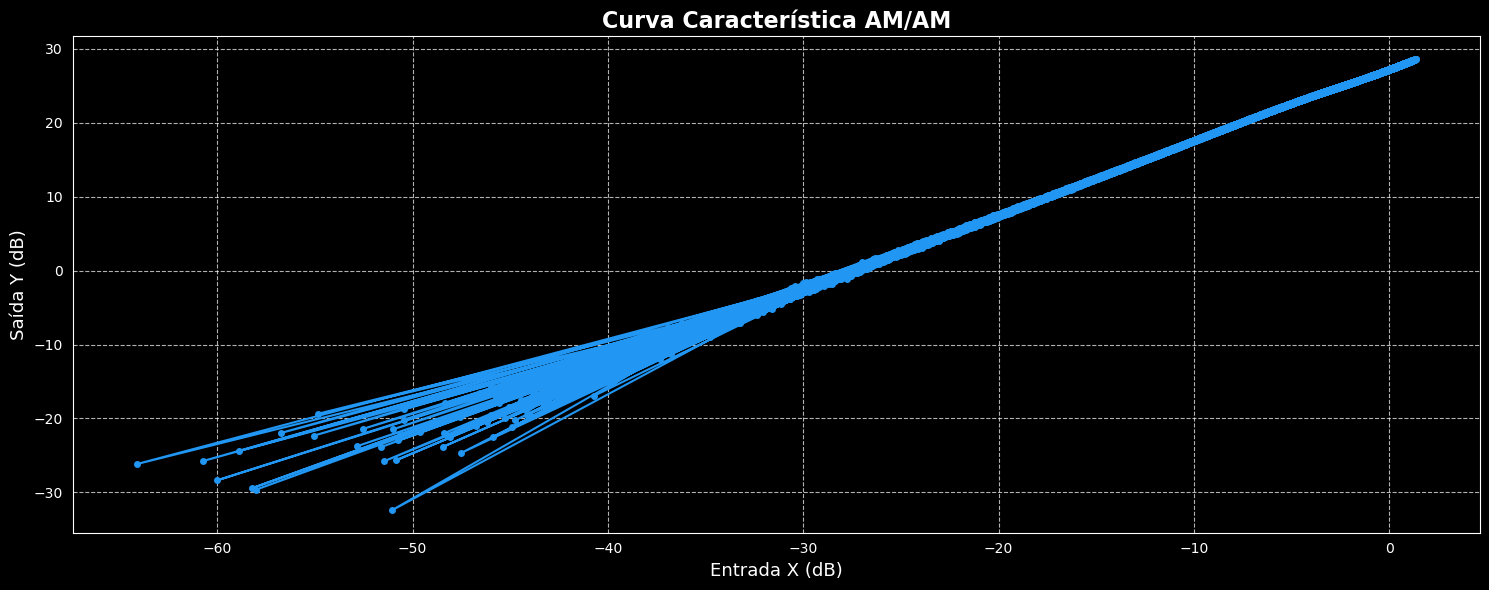

In [9]:
# Plot do gráfico AM/AM para Y x X
#plt.figure(figsize=(10, 6))
plt.plot(df_mag["MAG_Input_Decibel"], df_mag["MAG_Output_Decibel"],
         marker='o', markersize=4, linewidth=1.5, color='#2196F3')
plt.xlabel('Entrada X (dB)', fontsize=13)
plt.ylabel('Saída Y (dB)', fontsize=13)
plt.title('Curva Característica AM/AM', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Análise da Curva
Ao analisar o gráfico, pode-se concluir que:

**1 - Região de Baixa Potência (Entrada: ~65 dB a -45 dB)**
> Observa-se que existe grande dispersão dos pontos

Os pontos estão muito espalhados nesta região. A saída varia entre -32 dB e -18 dB, para entradas similares, o que indica **alta sensibilidade ao ruído** em sinais de baixa potência. Além disso, o PA tem dificuldades em manter um comportamento consistente com sinais fracos. A relação sinal-ruído (SNR) é baixa nesta faixa, o que explica a dispersão.

**2 - Região de Média Potência (Entrada: -45 dB a -20 dB)**
> Observa-se os pontos começam a convergir

Os dados começam a se alinhar em uma tendência mais definida e a dispersão diminui gradualmente. O comportamento começa a se aproximar de uma relação linear (reta) e o ganho do amplificador está se estabilizando.

**3 - Região de Alta Potência (Entrada: -20 dB a 0 dB)**
> Observa-se que o comportamento é quase perfeitamente linear

Os pontos formar uma linha reta bem definida e a saída vai de aproximadamente +5 dB até +28 dB. O PA opera de forma previsível e consistente, enquanto a dispersão é mínima. Esta é a região ideal de operação do PA.

#### Estimativa do ganho
    Ganho ≈ Saída(dB) - Entrada(dB)

    Na região linear (alta potência):
      Entrada ≈  0 dB  → Saída ≈ +28 dB
      Entrada ≈ -20 dB → Saída ≈ +7 dB

      Ganho ≈ 28 - 0 = 28 dB
      Ganho ≈ 7 - (-20) = 27 dB
    Ganho aproximado do amplificador: ~27-28 dB

<span style="color:grey">A presença de várias linhas paralelas pode indicar: </span>

<span style="color:grey">1. Efeito de memória do amplificador: O comportamento depende não só do sinal atual, mas também de sinais anteriores </span>

<span style="color:grey">2. Múltiplas frequências: Os dados podem conter sinais em diferentes frequências, cada uma com um ganho ligeiramente diferente </span>

<span style="color:grey">3. Variação temporal: Mudanças de temperatura ou condições de operação ao longo do tempo </span>

<span style="color:grey">4. Dados não ordenados: Os pontos estão conectados por linhas na ordem do DataFrame e não por ordem crescente de potência de entrada </span>

### Célula 08 - Ordenação de Dados e Binning

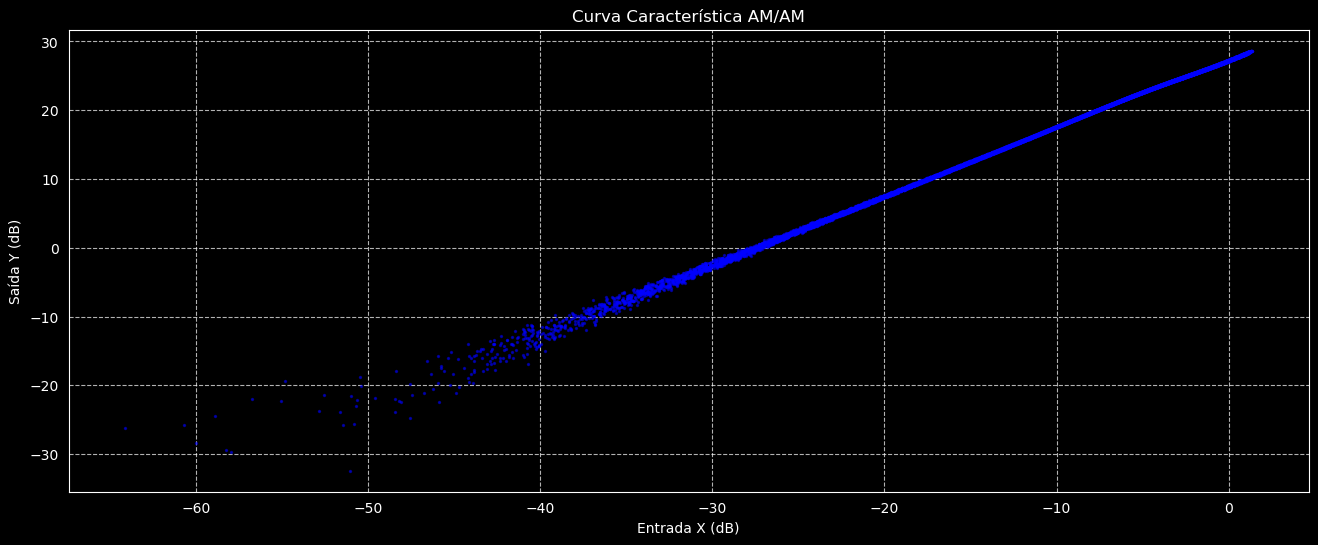

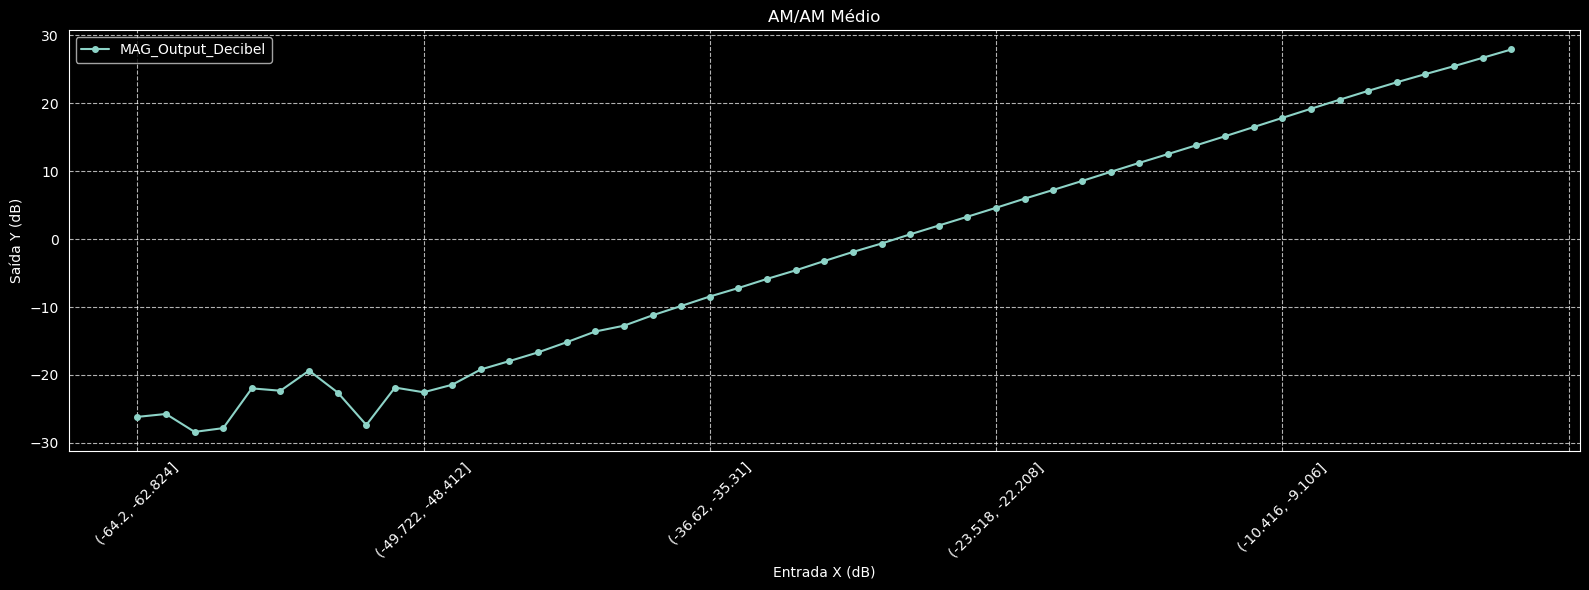

In [10]:
# 1. Ordenar os dados por potência de entrada
df_mag_sorted = df_mag.sort_values("MAG_Input_Decibel")

# 2. Plotar apenas os pontos (sem linhas conectando)
plt.figure(figsize=(16, 6))
plt.scatter(df_mag["MAG_Input_Decibel"],
            df_mag["MAG_Output_Decibel"],
            s=2, alpha=0.5, color='blue')
plt.xlabel("Entrada X (dB)")
plt.ylabel("Saída Y (dB)")
plt.title("Curva Característica AM/AM")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. Ou usar média por faixas de potência (binning)
# Criar bins de potência de entrada
df_mag["Input_Bin"] = pd.cut(df_mag["MAG_Input_Decibel"], bins=50)

# Agrupar por bin e calcular a média (sem warning)
df_avg = df_mag.groupby("Input_Bin", observed=True)[["MAG_Output_Decibel"]].mean()

# Plotar a curva AM/AM média
fig, ax = plt.subplots(figsize=(16, 6))
df_avg.plot(ax=ax, title="AM/AM Médio", marker='o', markersize=4, linewidth=1.5)
ax.set_xlabel("Entrada X (dB)")
ax.set_ylabel("Saída Y (dB)")
ax.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Em conclusão
> O gráfico mostra que o amplificador possui um ganho de aproximadamente 27-28 dB e opera de forma linear na região de alta potência. Na região de baixa potência, o ruído domina, causando grande dispersão nos dados. Não se observa compressão de ganho (saturação) na faixa de potência medida, o que sugere que o amplificador está operando abaixo do seu ponto de compressão de 1 dB (P1dB).

### Célula 09 - Análise da Entrada e Saída como Séries Temporais
O objetivo é visualizar como os sinais de Entrada e Saída do PA se comportam ao longo do tempo (amostra por amostra).

Diferente do gráfico AM/AM (que mostra saída vs entrada), aqui quer-se observar cada sinal individualmente, como se fosse uma série temporal, onde:
- Eixo X: Índice da amostra (representa o tempo)
- Eixo Y: Magnitude do sinal em dB

#### Desta maneira, deve ser possível observar nos gráficos:
    1. FORMATO DO SINAL:
       ┌───────────────────────────────────────────────┐
       │ A entrada e a saída têm formatos similares?   │
       │ → SIM: O amplificador está "copiando" o       │
       │        sinal com ganho (comportamento normal) │
       │ → NÃO: Pode haver distorção significativa     │
       └───────────────────────────────────────────────┘

    2. AMPLITUDE (FAIXA DE VALORES):
       ┌───────────────────────────────────────────────┐
       │ Entrada: ex. -65 dB a 0 dB                    │
       │ Saída:   ex. -32 dB a +28 dB                  │
       │ Diferença ≈ Ganho do amplificador             │
       └───────────────────────────────────────────────┘

    3. RUÍDO / DISPERSÃO:
       ┌───────────────────────────────────────────────┐
       │ Variações rápidas e aleatórias indicam ruído  │
       │ Regiões suaves indicam sinal "limpo"          │
       └───────────────────────────────────────────────┘

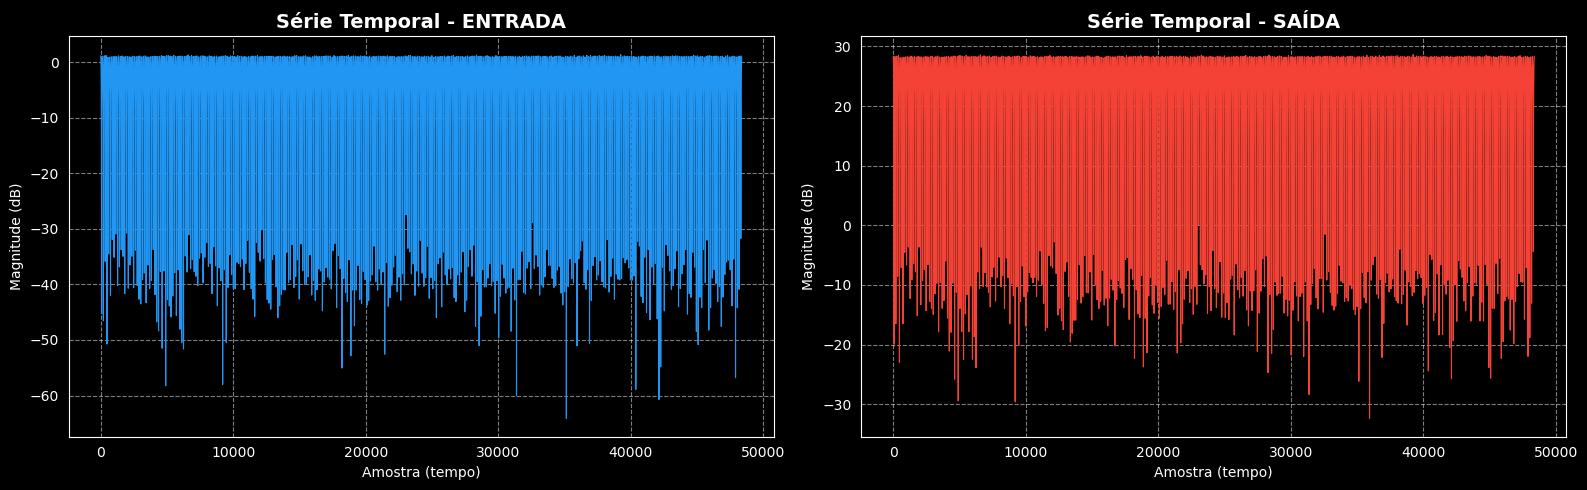

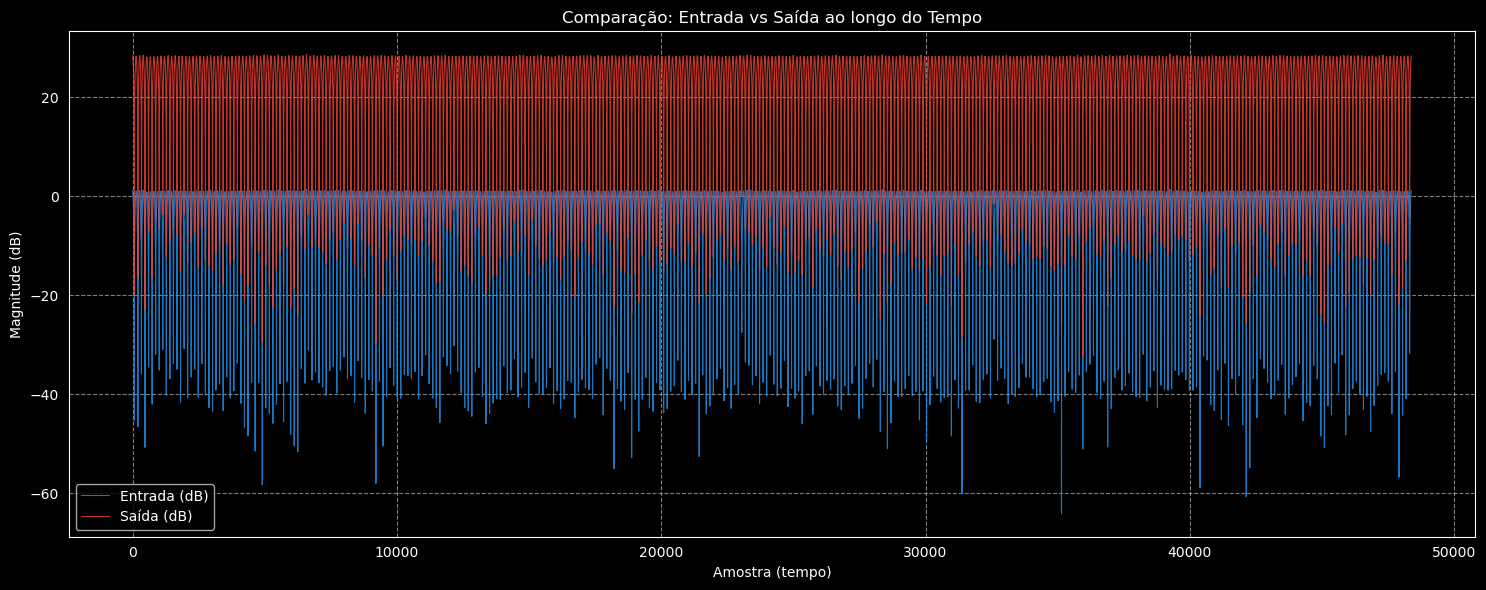

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico da ENTRADA
axes[0].plot(df_mag['MAG_Input_Decibel'].values,
             color='#2196F3', linewidth=0.8)
axes[0].set_title('Série Temporal - ENTRADA', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Amostra (tempo)')
axes[0].set_ylabel('Magnitude (dB)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gráfico da SAÍDA
axes[1].plot(df_mag['MAG_Output_Decibel'].values,
             color='#f44336', linewidth=0.8)
axes[1].set_title('Série Temporal - SAÍDA', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Amostra (tempo)')
axes[1].set_ylabel('Magnitude (dB)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Ou plotar ambos NO MESMO gráfico para comparação direta
plt.figure(figsize=(15, 6))
plt.plot(df_mag['MAG_Input_Decibel'].values,
         label='Entrada (dB)', color='#2196F3', linewidth=0.8, alpha=0.8)
plt.plot(df_mag['MAG_Output_Decibel'].values,
         label='Saída (dB)', color='#f44336', linewidth=0.8, alpha=0.8)
plt.xlabel('Amostra (tempo)')
plt.ylabel('Magnitude (dB)')
plt.title('Comparação: Entrada vs Saída ao longo do Tempo')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Análise dos Gráficos de Série Temporal

#### Gráfico 01 - Série Temporal devido a <span style="color:#2196F3"> Entrada </span>

    Magnitude (dB)
      +1 │████████████████████████████████████████  ← Picos frequentes (sinal forte)
         │████████████████████████████████████████
     -10 │████████████████████████████████████████
         │
     -30 │█ █ ██ █  █ ██  █  █ █ ██ █  █ █  █ █  ← Região intermediária
         │
     -50 │ █   █    █    █      █    █      █      ← Vales profundos (sinal fraco)
         │
     -65 │  █        █              █              ← Mínimos extremos (ruído?)
         ┼────────────────────────────────────────
         0              Amostras              50000

O sinal de entrada apresenta um comporamento típico de um sinal de comunicação modulado, com picos frequentes próximos de 0 dB (potência alta), vales profundos que caem até -65 db (momentos de baixa potência) e alta razão pico-a-média (PAPR) de aproximadamente 66 dB.

#### Gráfico 02 - Série Temporal devido a <span style="color:#f44336"> Saída </span>

    Magnitude (dB)
     +28 │████████████████████████████████████████  ← Picos frequentes (amplificado)
         │████████████████████████████████████████
     +10 │████████████████████████████████████████
         │
     -10 │█ █ ██ █  █ ██  █  █ █ ██ █  █ █  █ █  ← Região intermediária
         │
     -20 │ █   █    █    █      █    █      █      ← Vales
         │
     -30 │  █        █              █              ← Mínimos
         ┼────────────────────────────────────────
         0              Amostras              50000

A saída é o sinal de entrada amplificado, com formato similar à entrada (o amplificador "copia" o sinal), existe um deslocamento vertical de aproximadamente +27 dB (ganho do PA) e faixa dinâmica comprimida (58 dB vs 66 dB da entrada).

#### Gráfico 03 - Comparação <span style="color:#2196F3"> Entrada </span> vs <span style="color:#f44336"> Saída </span>

    Magnitude (dB)
     +28 │ ██ VERMELHO ██████████████████████████  ← Saída (amplificada)
         │ ████████████████████████████████████████
     +10 │ ████████████████████████████████████████
         │
      +1 │ ██ AZUL ████████████████████████████████ ← Entrada (original)
         │ ████████████████████████████████████████
     -10 │ ████████████████████████████████████████
         │
     -30 │ █ █ AZUL █  █ ██  █  █ █ ██ █  █ █  █  ← Vales da entrada
         │
     -50 │  █   █    █    █      █    █      █     ← Entrada em baixa potência
         │
     -65 │   █        █              █             ← Mínimos da entrada
         ┼────────────────────────────────────────
         0              Amostras              50000

<br><br>

---
| Métrica | Entrada | Saída | Diferença (Ganho/Efeito) |
| :--- | :---: | :---: | :--- |
| **Máximo** | +1 dB | +28 dB | +27 dB (Ganho total) |
| **Mínimo** | -65 dB | -30 dB | +35 dB (Ganho nos mínimos) |
| **Faixa Dinâmica** | **66 dB** | **58 dB** | **-8 dB (Compressão!)** |

Observa-se a confirmação do ganho de ~27-28 dB observado na curva AM/AM.

A faixa dinâmica da Saída (58 dB) é menor que a da entrada (68 dB). Isso indica **compressão** nos sinais de alta potência (os picos estão sendo "achatados").

O PA amplifica mais os sinais fracos do que os sinais fortes, isto indica um comportamento ***não-linear**.

---
O sinal apresenta alta variação de amplitude, com picos frequentes de alta potência e vales profundos esporádicos (*PAPR - Peak-to-Average Power Ratio*). Isso é típíco em sinais de comunicação modernos OFDM como o 5G/6G e QAM.

Esses sinais são conhecidos por seu alto PAPR, o que representa um desafio para PAs, uma vez que eles precisam operar em uma faixa ampla de potências de entrada.


## Bloco 03 - Análise Estatística: Normalidade e Estacionaridade

>Para diagnósticos estatísticos é necessário compreender a natureza matemática de séries temporais.

Assim, o bloco segue três sub-etapas com lógica encadeada:

    Histogramas → Teste Shapiro + adicionais  → Testes KPSS + Dickey-Fuller
    (visual)       (normalidade)                    (estacionaridade)

---
### Célula 10 - Análise da Distribuição dos Sinais (Histogramas Individuais)

O objetivo é visualizar a distribuição estatística das partes Real e Imaginária dos sinais de Entrada e Saída do PA, através de histogramas individuais.

Diferente da série temporal (que mostra a evolução no tempo), aqui quer-se observar como os valores se distribuem, ou seja, quais valores ocorrem com mais ou menos frequência.

- Eixo X: Valor da amplitude do sinal (parte Real ou Imaginária)
- Eixo Y: Frequência de ocorrência (quantas vezes cada valor aparece)

#### Desta maneira, deve ser possível observar nos gráficos:

    1. FORMATO DA DISTRIBUIÇÃO:
       ┌───────────────────────────────────────────────────┐
       │ A distribuição tem formato de sino (Gaussiana)?   │
       │ → SIM: Sinal típico de comunicação (OFDM, QAM)    │
       │        Comportamento estatisticamente previsível  │
       │ → NÃO: Pode indicar distorção, ceifamento         │
       │        (clipping) ou saturação do amplificador    │
       └───────────────────────────────────────────────────┘

    2. CENTRALIZAÇÃO (MÉDIA):
       ┌───────────────────────────────────────────────────┐
       │ A distribuição está centrada em zero?             │
       │ → SIM: Sinal sem componente DC (offset)           │
       │        Comportamento esperado para sinais RF      │
       │ → NÃO: Pode indicar um offset DC indesejado       │
       │        ou erro de medição/calibração              │
       └───────────────────────────────────────────────────┘

    3. LARGURA (DESVIO PADRÃO):
       ┌───────────────────────────────────────────────────┐
       │ Comparar a largura entre Entrada e Saída:         │
       │ → Saída MAIS LARGA: O amplificador está           │
       │   aumentando a amplitude (ganho aplicado)         │
       │ → Saída MAIS ESTREITA: Possível compressão        │
       │   ou atenuação do sinal                           │
       └───────────────────────────────────────────────────┘

    4. SIMETRIA:
       ┌───────────────────────────────────────────────────┐
       │ A distribuição é simétrica em torno de zero?      │
       │ → SIM: Sinal balanceado, sem distorção ímpar      │
       │ → NÃO: Pode indicar distorção não-linear          │
       │        ou assimetria no circuito do amplificador  │
       └───────────────────────────────────────────────────┘

In [ ]:
def plot_histograms_dark(df_input, df_output, bins=1000):

    plt.style.use('dark_background')

    config = [
        {"data": df_input["Xreal"],  "title": "Entrada Real (Xreal)",      "color": "#2196F3", "edge": "#0D47A1"},  # Azul Escuro
        {"data": df_input["Ximg"],   "title": "Entrada Imaginária (Ximg)", "color": "#64B5F6", "edge": "#1565C0"},  # Azul Médio
        {"data": df_output["Yreal"], "title": "Saída Real (Yreal)",        "color": "#f44336", "edge": "#B71C1C"},  # Vermelho Escuro
        {"data": df_output["Yimg"],  "title": "Saída Imaginária (Yimg)",   "color": "#FF8A80", "edge": "#C62828"},  # Vermelho Médio
    ]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for ax, cfg in zip(axes, config):
        ax.hist(cfg["data"], bins=bins,
                edgecolor=cfg["edge"],    # Cor da borda personalizada
                color=cfg["color"], alpha=0.85)
        ax.set_title(f'Histograma - {cfg["title"]}',
                     fontsize=14, fontweight='bold', color='white')
        ax.set_xlabel('Valor', color='white', fontsize=12)
        ax.set_ylabel('Frequência', color='white', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.2, color='gray')

        mean = cfg["data"].mean()
        std = cfg["data"].std()
        ax.axvline(mean, color='#FFFFFF', linestyle='--', linewidth=1.5,
                   label=f'Média: {mean:.4f}')
        ax.axvline(mean + std, color='#AAAAAA', linestyle=':', linewidth=1,
                   label=f'Std: ±{std:.4f}')
        ax.axvline(mean - std, color='#AAAAAA', linestyle=':', linewidth=1)
        ax.legend(fontsize=10, facecolor='black', edgecolor='white',
                  labelcolor='white')

    plt.suptitle('Distribuição dos Sinais de Entrada e Saída',
                 fontsize=18, fontweight='bold', color='white', y=1.02)
    plt.tight_layout()
    plt.show()

plot_histograms_dark(df_input, df_output, bins=1000)

### Célula 11 - Comparação das Distribuições: Entrada vs Saída (Histogramas Sobrepostos)

O objetivo é comparar diretamente as distribuições dos sinais de Entrada e Saída do PA, sobrepondo os histogramas no mesmo gráfico, separados em Parte Real e Parte Imaginária.

Diferente dos histogramas individuais (que analisam cada sinal isoladamente), aqui quer-se observar como o amplificador altera a distribuição do sinal, visualizando entrada e saída simultaneamente.

- Eixo X: Valor da amplitude do sinal (parte Real ou Imaginária)
- Eixo Y: Frequência de ocorrência
- Azul: Sinal de Entrada
- Vermelho: Sinal de Saída

#### Desta maneira, deve ser possível observar nos gráficos:

    1. EXPANSÃO DA DISTRIBUIÇÃO (GANHO):
       ┌───────────────────────────────────────────────────┐
       │ A distribuição vermelha (saída) é mais larga      │
       │ que a azul (entrada)?                             │
       │ → SIM: O amplificador está aplicando GANHO,       │
       │        aumentando a amplitude do sinal            │
       │ → A razão entre as larguras é proporcional        │
       │   ao ganho linear do amplificador                 │
       └───────────────────────────────────────────────────┘

    2. DEFORMAÇÃO DA DISTRIBUIÇÃO (NÃO-LINEARIDADE):
       ┌───────────────────────────────────────────────────┐
       │ A saída mantém o mesmo FORMATO da entrada?        │
       │ → SIM: Amplificador operando na região LINEAR     │
       │        (distribuição apenas "esticada")           │
       │ → NÃO: Indica distorção NÃO-LINEAR                │
       │   • Picos achatados → Compressão/Saturação        │
       │   • Caudas cortadas → Ceifamento (clipping)       │
       │   • Formato diferente → Distorção harmônica       │
       └───────────────────────────────────────────────────┘

    3. REGIÃO DE SOBREPOSIÇÃO (OVERLAP):
       ┌───────────────────────────────────────────────────┐
       │ A região ROXA (sobreposição azul + vermelho)      │
       │ indica onde os valores de entrada e saída         │
       │ coincidem.                                        │
       │ → Pouca sobreposição: Alto ganho (grande          │
       │   diferença entre entrada e saída)                │
       │ → Muita sobreposição: Baixo ganho ou              │
       │   faixas de operação similares                    │
       └───────────────────────────────────────────────────┘

    4. ESTATÍSTICAS (MÉDIA E DESVIO PADRÃO):
       ┌───────────────────────────────────────────────────┐
       │ As linhas tracejadas mostram a MÉDIA de cada      │
       │ distribuição e as linhas pontilhadas mostram      │
       │ o DESVIO PADRÃO (±1σ).                            │
       │                                                   │
       │ → Médias próximas de zero: Sem offset DC          │
       │ → Desvio padrão da saída > entrada: Ganho         │
       │ → Razão dos desvios ≈ Ganho linear em escala      │
       │   de amplitude                                    │
       └───────────────────────────────────────────────────┘

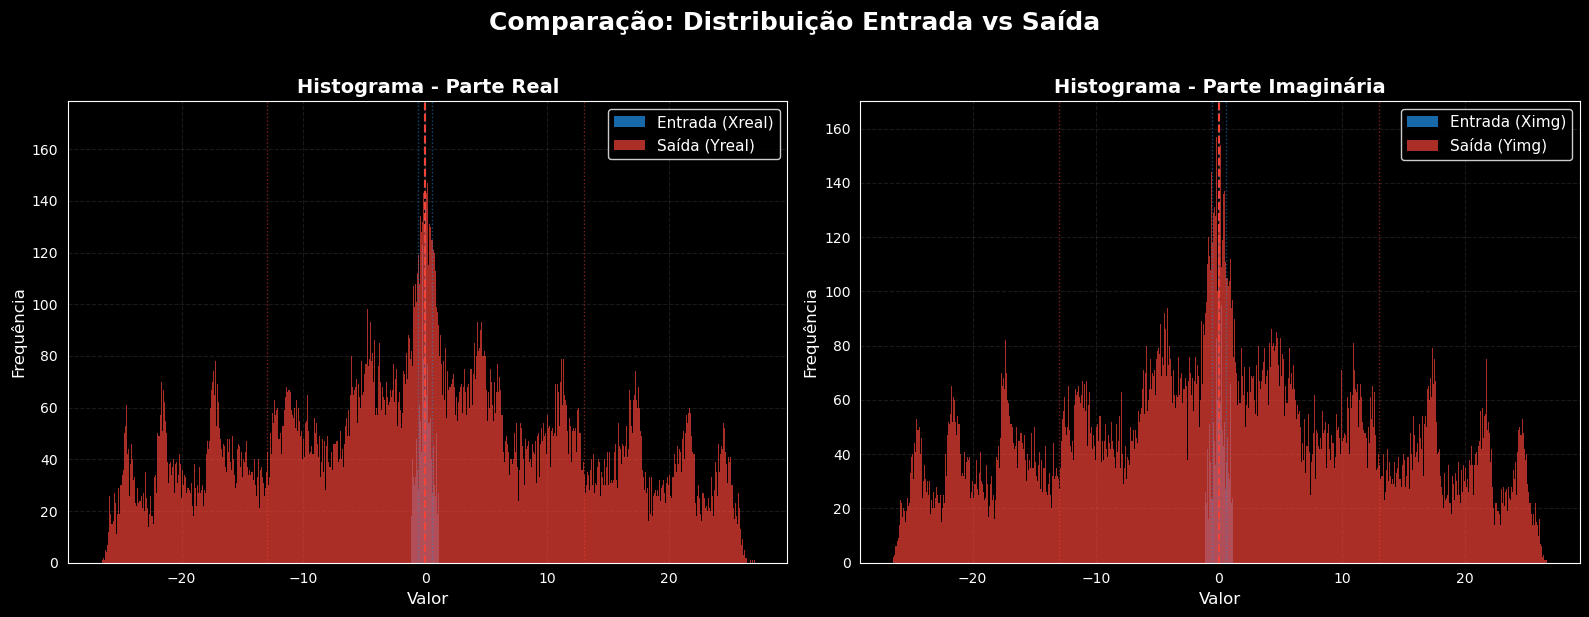

In [13]:
def plot_histogram_comparison(df_input, df_output, bins=1000,
                               dark_mode=True, figsize=(16, 6),
                               input_color='#2196F3', output_color='#f44336',
                               alpha=0.7, show_stats=True):
    """
    Plota histogramas sobrepostos comparando Entrada vs Saída
    para as partes Real e Imaginária dos sinais.

    Parameters:
    -----------
    df_input     : pd.DataFrame  -> DataFrame com colunas 'Xreal' e 'Ximg'
    df_output    : pd.DataFrame  -> DataFrame com colunas 'Yreal' e 'Yimg'
    bins         : int           -> Número de intervalos do histograma
    dark_mode    : bool          -> Ativar fundo preto (True/False)
    figsize      : tuple         -> Tamanho da figura (largura, altura)
    input_color  : str           -> Cor dos histogramas de entrada
    output_color : str           -> Cor dos histogramas de saída
    alpha        : float         -> Transparência (0 a 1)
    show_stats   : bool          -> Mostrar linhas de média e desvio padrão
    """

    # ============================================================
    # Configuração do estilo
    # ============================================================
    if dark_mode:
        plt.style.use('dark_background')
        text_color = 'white'
        grid_color = 'gray'
        legend_face = 'black'
        legend_edge = 'white'
    else:
        plt.style.use('default')
        text_color = 'black'
        grid_color = 'lightgray'
        legend_face = 'white'
        legend_edge = 'black'

    # ============================================================
    # Configuração dos gráficos
    # ============================================================
    config = [
        {
            "title": "Histograma - Parte Real",
            "input":  {"data": df_input["Xreal"],  "label": "Entrada (Xreal)"},
            "output": {"data": df_output["Yreal"], "label": "Saída (Yreal)"},
        },
        {
            "title": "Histograma - Parte Imaginária",
            "input":  {"data": df_input["Ximg"],  "label": "Entrada (Ximg)"},
            "output": {"data": df_output["Yimg"], "label": "Saída (Yimg)"},
        },
    ]

    # ============================================================
    # Plotagem
    # ============================================================
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for ax, cfg in zip(axes, config):

        # Histograma da ENTRADA
        ax.hist(cfg["input"]["data"], bins=bins, edgecolor='none',
                color=input_color, alpha=alpha, label=cfg["input"]["label"])

        # Histograma da SAÍDA
        ax.hist(cfg["output"]["data"], bins=bins, edgecolor='none',
                color=output_color, alpha=alpha, label=cfg["output"]["label"])

        # Estatísticas (média e desvio padrão)
        if show_stats:
            for data, color in [(cfg["input"]["data"], input_color),
                                (cfg["output"]["data"], output_color)]:
                mean = data.mean()
                std = data.std()
                ax.axvline(mean, color=color, linestyle='--', linewidth=1.5)
                ax.axvline(mean + std, color=color, linestyle=':', linewidth=1, alpha=0.5)
                ax.axvline(mean - std, color=color, linestyle=':', linewidth=1, alpha=0.5)

        # Estilo
        ax.set_title(cfg["title"], fontsize=14, fontweight='bold', color=text_color)
        ax.set_xlabel('Valor', color=text_color, fontsize=12)
        ax.set_ylabel('Frequência', color=text_color, fontsize=12)
        ax.legend(fontsize=11, facecolor=legend_face,
                  edgecolor=legend_edge, labelcolor=text_color)
        ax.grid(True, linestyle='--', alpha=0.2, color=grid_color)

    plt.suptitle('Comparação: Distribuição Entrada vs Saída',
                 fontsize=18, fontweight='bold', color=text_color, y=1.02)
    plt.tight_layout()
    plt.show()

plot_histogram_comparison(df_input, df_output)

### Célula 12 - Verificação da distribuição (Teste de Shapiro-Wilk)

> É um dos testes estastísticos mais utilizados para verificar se um conjunto de dados segue um distribuição normal (Gaussiana).

    Funcionamento do Teste de Shapiro-Wilk
    ═══════════════════════════════════════════════════

    Hipóteses:
        H0: Os dados vêm de uma distribuição normal
        H1: Os dados NÃO vêm de uma distribuição normal

                        p-valor
        ◄────────────────┼────────────────►
        0              alpha            1
                       (0.05)

        ████████████████│░░░░░░░░░░░░░░░░
        REJEITA H0      │  FALHA EM REJEITAR H0
        (Não Normal)    │  (Parece Normal)

        p ≤ 0.05        │  p > 0.05
        "Dados NÃO      │  "Dados PARECEM
         são normais"   │   ser normais"

In [14]:
from scipy.stats import shapiro
def calcula_shapiro_teste(serie, nome="Dados"):
    if len(serie) > 5001:
        print(f"Shapiro-Wilk limitado a 5000 amostras."
              f" Usando amostras aleatórias de {len(serie)} dados.")
        serie_teste = serie.sample(5000, random_state=42)
    else:
        serie_teste = serie

    stat, p = shapiro(serie_teste)
    alpha = 0.05

    if p > alpha:
        resultado = "Falha em rejeitar H0: os dados parecem normais"
        normal = True
    else:
        resultado = "Rejeita H0: os dados não parecem normais"
        normal = False

    print(f"{'='*50}")
    print(f"Teste de Shapiro-Wilk: {nome}")
    print(f"{'='*50}")
    print(f"  Estatística de teste = {stat:.6f}")
    print(f"  p-valor              = {p:.6e}")
    print(f"  Alpha                = {alpha}")
    print(f"  Resultado: {resultado}")
    print(f"{'='*50}\n")

    return {"stat": stat, "p_valor": p, "normal": normal}

# Testar cada componente do sinal
resultado_xreal = calcula_shapiro_teste(df_input["Xreal"],  "Entrada Real (Xreal)")
resultado_ximg  = calcula_shapiro_teste(df_input["Ximg"],   "Entrada Imaginária (Ximg)")
resultado_yreal = calcula_shapiro_teste(df_output["Yreal"], "Saída Real (Yreal)")
resultado_yimg  = calcula_shapiro_teste(df_output["Yimg"],  "Saída Imaginária (Yimg)")


Shapiro-Wilk limitado a 5000 amostras. Usando amostras aleatórias de 48383 dados.
Teste de Shapiro-Wilk: Entrada Real (Xreal)
  Estatística de teste = 0.982017
  p-valor              = 1.023608e-24
  Alpha                = 0.05
  Resultado: Rejeita H0: os dados não parecem normais

Shapiro-Wilk limitado a 5000 amostras. Usando amostras aleatórias de 48383 dados.
Teste de Shapiro-Wilk: Entrada Imaginária (Ximg)
  Estatística de teste = 0.980703
  p-valor              = 1.498454e-25
  Alpha                = 0.05
  Resultado: Rejeita H0: os dados não parecem normais

Shapiro-Wilk limitado a 5000 amostras. Usando amostras aleatórias de 48383 dados.
Teste de Shapiro-Wilk: Saída Real (Yreal)
  Estatística de teste = 0.981439
  p-valor              = 4.339728e-25
  Alpha                = 0.05
  Resultado: Rejeita H0: os dados não parecem normais

Shapiro-Wilk limitado a 5000 amostras. Usando amostras aleatórias de 48383 dados.
Teste de Shapiro-Wilk: Saída Imaginária (Yimg)
  Estatística de te

### Célula 13 - Análise Complementar de Normalidade

>Como o teste de Shapiro-Wilk é extremamente sensível com grandes amostras (N > 5000), é recomendável utilizar testes complementares e métricas de forma para obter uma análise mais robusta sobre a distribuição dos dados.

#### Testes Utilizados:
1. Teste de D'Agostino-Pearson: Avalia a normalidade com base na assimetria (skewness) e curtose (kurtosis) dos dados. É mais robusto que o Shapiro-Wilk para grandes amostras.


2. Teste de Kolmogorov-Smirnov (KS): Compara a distribuição acumulada dos dados com a distribuição normal teórica. Mede a maior distância entre as duas curvas.


3.  Métricas de Forma (Assimetria e Curtose): Medem **quantitativamente** o quanto a distribuição se desvia de uma normal perfeita.


#### Comparativo de Testes de Normalidade

| Teste | O que avalia | Sensibilidade |
| :--- | :--- | :--- |
| **Shapiro-Wilk** | Normalidade geral | Alta (N < 5000) |
| **D'Agostino-Pearson** | Assimetria + Curtose | Média-Alta |
| **Kolmogorov-Smirnov** | Distribuição acumulada | Média |
| **Skewness** | Simetria da distribuição | Métrica (não teste) |
| **Kurtosis** | Peso das caudas | Métrica (não teste) |

---

#### Interpretação Conjunta

* **Se TODOS os testes rejeitam H0:**
    * Forte evidência de **NÃO normalidade**.
* **Se APENAS Shapiro-Wilk rejeita:**
    * Pode ser sensibilidade excessiva do teste;
    * Os dados podem ser "suficientemente normais" para a análise.
* **Se Skewness ≈ 0 e Kurtosis ≈ 0:**
    * Os dados são **APROXIMADAMENTE normais**;
    * Desvios são pequenos e possivelmente irrelevantes para fins práticos de engenharia.

In [15]:
from scipy.stats import normaltest, kstest, kurtosis, skew

def analise_normalidade_completa(serie, nome="Dados"):

    # Amostra para testes (limitado a 5000)
    if len(serie) > 5000:
        amostra = serie.sample(5000, random_state=42)
    else:
        amostra = serie

    print(f"{'='*55}")
    print(f"  Análise de Normalidade: {nome}")
    print(f"{'='*55}")

    # 1. Teste de Shapiro-Wilk
    stat_sw, p_sw = shapiro(amostra)
    print(f"\n  1. Shapiro-Wilk:")
    print(f"     Estatística = {stat_sw:.6f} | p-valor = {p_sw:.2e}")

    # 2. Teste de D'Agostino-Pearson
    stat_dp, p_dp = normaltest(amostra)
    print(f"\n  2. D'Agostino-Pearson:")
    print(f"     Estatística = {stat_dp:.6f} | p-valor = {p_dp:.2e}")

    # 3. Teste de Kolmogorov-Smirnov
    stat_ks, p_ks = kstest(amostra, 'norm',
                            args=(amostra.mean(), amostra.std()))
    print(f"\n  3. Kolmogorov-Smirnov:")
    print(f"     Estatística = {stat_ks:.6f} | p-valor = {p_ks:.2e}")

    # 4. Métricas de forma
    sk = skew(amostra)
    kt = kurtosis(amostra)
    print(f"\n  4. Métricas de Forma:")
    print(f"     Assimetria (Skewness) = {sk:.6f}  (Normal = 0)")
    print(f"     Curtose (Kurtosis)    = {kt:.6f}  (Normal = 0)")

    # Interpretação da curtose
    if kt > 0:
        tipo_curtose = "Leptocúrtica (caudas pesadas, pico agudo)"
    elif kt < 0:
        tipo_curtose = "Platicúrtica (caudas leves, pico achatado)"
    else:
        tipo_curtose = "Mesocúrtica (normal)"
    print(f"     Tipo: {tipo_curtose}")

    print(f"\n{'='*55}\n")

# Uso:
analise_normalidade_completa(df_input["Xreal"],  "Entrada Real (Xreal)")
analise_normalidade_completa(df_input["Ximg"],   "Entrada Imaginária (Ximg)")
analise_normalidade_completa(df_output["Yreal"], "Saída Real (Yreal)")
analise_normalidade_completa(df_output["Yimg"],  "Saída Imaginária (Yimg)")

  Análise de Normalidade: Entrada Real (Xreal)

  1. Shapiro-Wilk:
     Estatística = 0.982017 | p-valor = 1.02e-24

  2. D'Agostino-Pearson:
     Estatística = 272.281753 | p-valor = 7.49e-60

  3. Kolmogorov-Smirnov:
     Estatística = 0.034774 | p-valor = 1.09e-05

  4. Métricas de Forma:
     Assimetria (Skewness) = -0.006643  (Normal = 0)
     Curtose (Kurtosis)    = -0.707965  (Normal = 0)
     Tipo: Platicúrtica (caudas leves, pico achatado)


  Análise de Normalidade: Entrada Imaginária (Ximg)

  1. Shapiro-Wilk:
     Estatística = 0.980703 | p-valor = 1.50e-25

  2. D'Agostino-Pearson:
     Estatística = 339.136411 | p-valor = 2.28e-74

  3. Kolmogorov-Smirnov:
     Estatística = 0.038820 | p-valor = 5.53e-07

  4. Métricas de Forma:
     Assimetria (Skewness) = -0.006485  (Normal = 0)
     Curtose (Kurtosis)    = -0.754181  (Normal = 0)
     Tipo: Platicúrtica (caudas leves, pico achatado)


  Análise de Normalidade: Saída Real (Yreal)

  1. Shapiro-Wilk:
     Estatística = 0

#### Conlusão da Análise

1. **Rejeição da Hipótese Nula:** TODOS os sinais (entrada e saída) foram rejeitados como normais pelo teste de Shapiro-Wilk.
2. **Quase-Normalidade:** Porém, as estatísticas de teste ($\approx 0,98$) indicam que os dados são **APROXIMADAMENTE normais**, com pequenos desvios detectados pela alta sensibilidade do teste.
3. **Distorção Identificada:** A **SAÍDA** é ligeiramente MENOS normal que a **ENTRADA**, confirmando que o amplificador introduz distorção não-linear que altera a distribuição do sinal.
4. **Uso Prático:** Para fins práticos de engenharia, os sinais podem ser tratados como **"aproximadamente Gaussianos"**, especialmente a entrada.

### Célula 14 - Visualização Diagnóstica
> O *Q-Q Plot* (Quantile-Quantile Plot) é uma ferramenta gráfica para avaliar visualmente se os dados seguem uma distribuição normal. ele complementa os testes estastísticos (Shapiro-Wilk, KPSS, ADF) ao permitir identificar onde e como os dados se desviam da normalidade.

#### Q-Q Plot

    Funcionamento do Q-Q Plot
    ═══════════════════════════════════════════════════

    Compara os QUANTIS dos seus dados (eixo Y) com os
    QUANTIS TEÓRICOS de uma distribuição normal (eixo X).

    → Se os dados forem normais:
      Os pontos seguem a LINHA DIAGONAL vermelha

    → Se os dados NÃO forem normais:
      Os pontos se DESVIAM da linha diagonal

    Quantis dos Dados (Y)
        │                    ╱ ·
        │                  ╱· ·
        │               ╱ ·
        │            ╱·· ← Pontos sobre a linha = NORMAL
        │          ╱·
        │       ·╱
        │    · ╱
        │  · ╱
        │·╱
        ┼──────────────────────
        Quantis Teóricos (X)

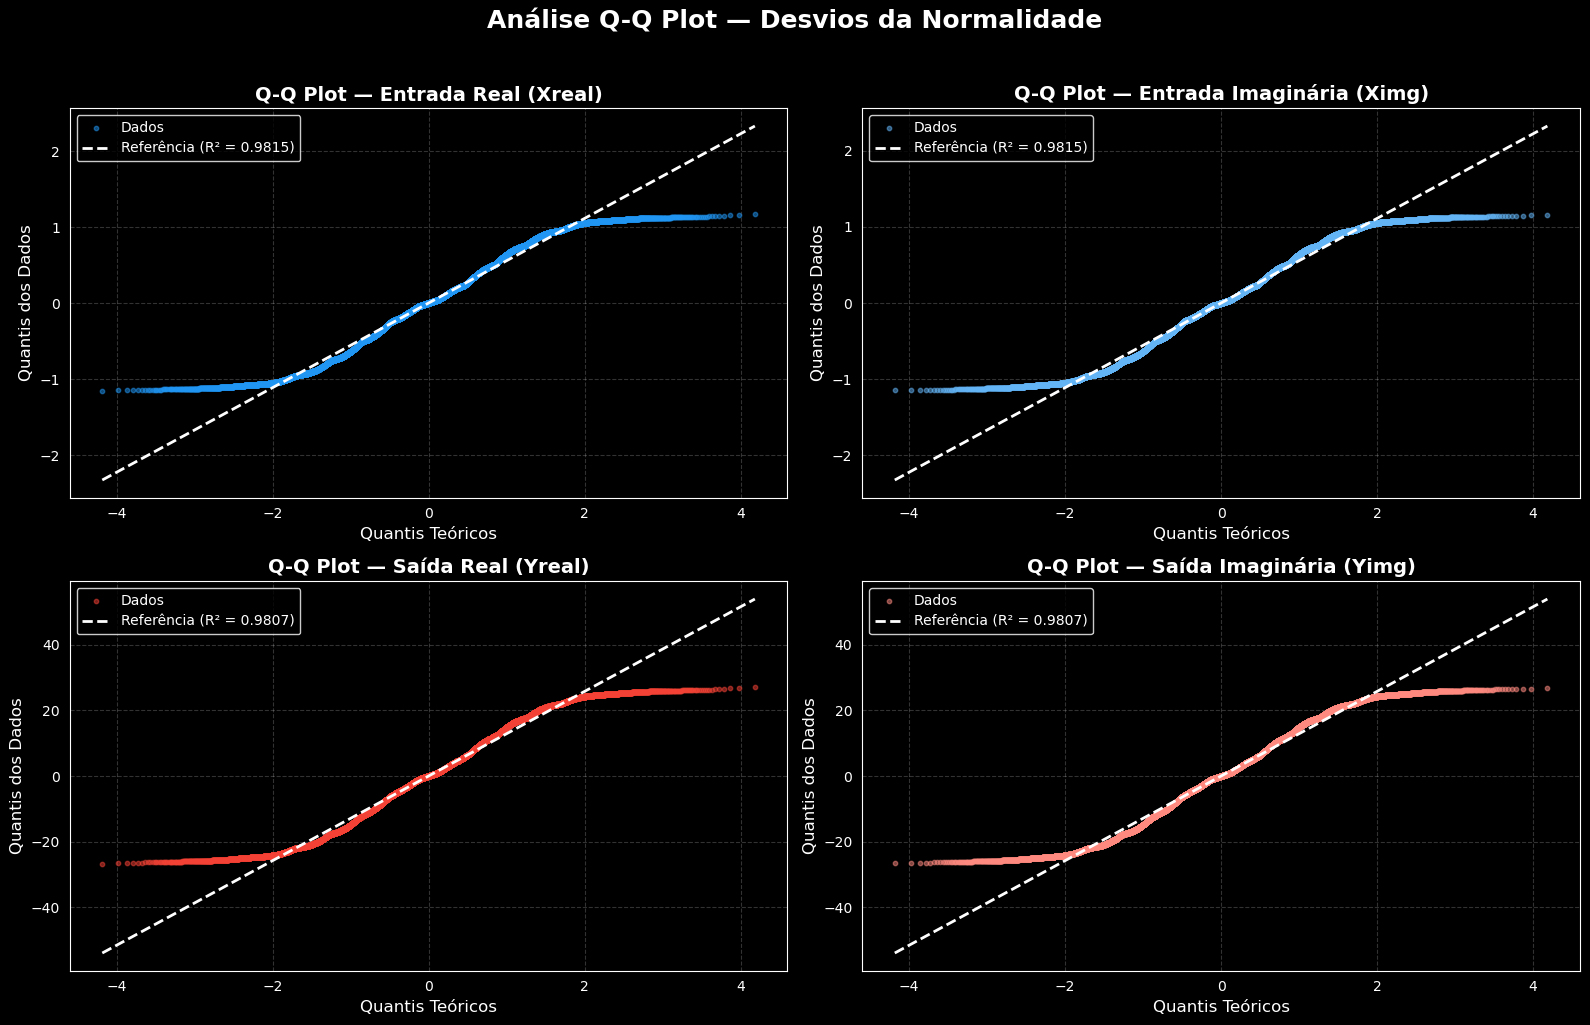

In [22]:
from scipy.stats import probplot

def plot_qq(df_input, df_output, dark_mode=True, figsize=(16, 10)):
    """
    Plota Q-Q Plots para todos os sinais (Entrada e Saída,
    partes Real e Imaginária).

    Parameters:
    -----------
    df_input   : pd.DataFrame -> DataFrame com 'Xreal' e 'Ximg'
    df_output  : pd.DataFrame -> DataFrame com 'Yreal' e 'Yimg'
    dark_mode  : bool         -> Ativar fundo preto
    figsize    : tuple        -> Tamanho da figura
    """

    if dark_mode:
        plt.style.use('dark_background')
        text_color = 'white'
        point_color = ['#2196F3', '#64B5F6', '#f44336', '#FF8A80']
        line_color = '#FFFFFF'
    else:
        plt.style.use('default')
        text_color = 'black'
        point_color = ['#2196F3', '#64B5F6', '#f44336', '#FF8A80']
        line_color = 'red'

    config = [
        {"data": df_input["Xreal"],  "title": "Q-Q Plot — Entrada Real (Xreal)"},
        {"data": df_input["Ximg"],   "title": "Q-Q Plot — Entrada Imaginária (Ximg)"},
        {"data": df_output["Yreal"], "title": "Q-Q Plot — Saída Real (Yreal)"},
        {"data": df_output["Yimg"],  "title": "Q-Q Plot — Saída Imaginária (Yimg)"},
    ]

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()

    for ax, cfg, pc in zip(axes, config, point_color):

        # Gera o Q-Q Plot
        (osm, osr), (slope, intercept, r) = probplot(cfg["data"], dist="norm")

        # Plota os pontos
        ax.scatter(osm, osr, color=pc, alpha=0.5, s=10, label='Dados')

        # Plota a linha de referência (diagonal)
        ax.plot(osm, slope * osm + intercept,
                color=line_color, linewidth=2,
                linestyle='--', label=f'Referência (R² = {r**2:.4f})')

        # Estilo
        ax.set_title(cfg["title"], fontsize=14, fontweight='bold', color=text_color)
        ax.set_xlabel('Quantis Teóricos', color=text_color, fontsize=12)
        ax.set_ylabel('Quantis dos Dados', color=text_color, fontsize=12)
        ax.legend(fontsize=10, facecolor='black' if dark_mode else 'white',
                  edgecolor='white' if dark_mode else 'black',
                  labelcolor=text_color)
        ax.grid(True, linestyle='--', alpha=0.2)

    plt.suptitle('Análise Q-Q Plot — Desvios da Normalidade',
                 fontsize=18, fontweight='bold', color=text_color, y=1.02)
    plt.tight_layout()
    plt.show()

    plt.style.use('default')

# Uso:
plot_qq(df_input, df_output)

# Fundo branco:
# plot_qq(df_input, df_output, dark_mode=False)

#### Interpretação de Desvios

    1. DADOS PERFEITAMENTE NORMAIS:
       ┌─────────────────────────────────────────────┐
       │ Quantis Dados                               │
       │     │                 ·╱                    │
       │     │              ·╱                       │
       │     │           ·╱                          │
       │     │        ·╱    Pontos SOBRE a linha     │
       │     │     ·╱       → Distribuição normal    │
       │     │  ·╱          perfeita                 │
       │     │╱                                      │
       │     ┼────────────────                       │
       │     Quantis Teóricos                        │
       └─────────────────────────────────────────────┘

    2. CAUDAS PESADAS (Leptocúrtica, Kurtosis > 0):
       ┌─────────────────────────────────────────────┐
       │ Quantis Dados                               │
       │     │                    ·                  │
       │     │                 · ╱                   │
       │     │              ·╱                       │
       │     │           ·╱                          │
       │     │        ·╱                             │
       │     │     ·╱                                │
       │     │  ╱·                                   │
       │     │╱·                                     │
       │     ┼────────────────                       │
       │     Quantis Teóricos                        │
       │                                             │
       │  → Pontos curvam para CIMA à direita        │
       │    e para BAIXO à esquerda                  │
       │  → Mais valores EXTREMOS que o esperado     │
       │  → Caudas mais "pesadas" que a normal       │
       └─────────────────────────────────────────────┘

    3. CAUDAS LEVES (Platicúrtica, Kurtosis < 0):
       ┌─────────────────────────────────────────────┐
       │ Quantis Dados                               │
       │     │               ╱·                      │
       │     │             ╱·                        │
       │     │           ·╱                          │
       │     │        ·╱                             │
       │     │      ·╱                               │
       │     │    ·╱                                 │
       │     │  ·╱                                   │
       │     │·╱                                     │
       │     ┼────────────────                       │
       │     Quantis Teóricos                        │
       │                                             │
       │  → Pontos curvam para BAIXO à direita       │
       │    e para CIMA à esquerda                   │
       │  → Menos valores extremos que o esperado    │
       │  → Distribuição mais "achatada"             │
       └─────────────────────────────────────────────┘

    4. DISTRIBUIÇÃO ASSIMÉTRICA (Skewness ≠ 0):
       ┌─────────────────────────────────────────────┐
       │ Quantis Dados                               │
       │     │                       ·               │
       │     │                    ·                  │
       │     │                ·  ╱                   │
       │     │            · ╱                        │
       │     │         ·╱                            │
       │     │      ·╱                               │
       │     │   ·╱                                  │
       │     │·╱                                     │
       │     ┼────────────────                       │
       │     Quantis Teóricos                        │
       │                                             │
       │  → Curvatura em forma de "S"                │
       │  → Indica assimetria na distribuição        │
       └─────────────────────────────────────────────┘


#### Interpretação do R²

    ┌──────────────────────────────────────────────────────────┐
    │ R² (Coeficiente de Determinação):                        │
    │                                                          │
    │ → Mede o quão bem os pontos seguem a linha diagonal      │
    │ → Varia de 0 a 1                                         │
    │                                                          │
    │   R² = 1.0000  → Distribuição PERFEITAMENTE normal       │
    │   R² > 0.9900  → Distribuição muito próxima de normal    │
    │   R² > 0.9500  → Distribuição aproximadamente normal     │
    │   R² < 0.9500  → Desvios significativos da normalidade   │
    │                                                          │
    │ Exemplo dos dados:                                       │
    │   Xreal: R² = 0.9950 → Muito próximo de normal           │
    │   Yreal: R² = 0.9920 → Próximo, mas com mais desvio      │
    │                                                          │
    │ → Saída (Y) tende a ter R² MENOR que Entrada (X)         │
    │ → Isso confirma a distorção introduzida pelo PA          │
    └──────────────────────────────────────────────────────────┘

### Célula 15 - Teste de Estacionariedade
> O teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin) é um dos testes estatísticos mais utilizados para verificar se uma série temporal é estacionária, ou seja, se suas propriedades estatísticas (média, variância) permanecem constantes ao longo do tempo.

    Funcionamento do Teste KPSS
    ═══════════════════════════════════════════════════

    Hipóteses (Invertidas em relação ao Shapiro-Wilk!):
        H0: A série É estacionária
        H1: A série NÃO é estacionária (possui raiz unitária)

    ATENÇÃO: Diferente da maioria dos testes, no KPSS:
        → REJEITAR H0 = série NÃO estacionária (ruim)
        → NÃO rejeitar H0 = série É estacionária (bom)

                        p-valor
        ◄────────────────┼────────────────►
        0              alpha            1
                       (0.05)

        ████████████████│░░░░░░░░░░░░░░░░
        REJEITA H0      │  FALHA EM REJEITAR H0
        (Não Estac.)    │  (Estacionária)

        p ≤ 0.05        │  p > 0.05
        "Série NÃO é    │  "Série PARECE
         estacionária"  │   ser estacionária"

### Estacionariedade
> Uma série temporal é dita estacionária, quando suas propriedades estatísticas, tais como a média, variância e autocovariância, permanencem constantes ao longo do tempo.

    Série ESTACIONÁRIA:              Série NÃO ESTACIONÁRIA:

    Valor                             Valor
      │  ╱╲  ╱╲  ╱╲  ╱╲                │            ╱╲  ╱╲
      │ ╱  ╲╱  ╲╱  ╲╱  ╲               │        ╱╲╱   ╲╱  ╲
      │─────────────────── média       │    ╱╲╱╱
      │                                │  ╱╱        ← tendência
      │                                │╱╱            crescente
      ┼──────────────────              ┼──────────────────
      0     Tempo      N              0     Tempo      N

    → Média CONSTANTE ao longo         → Média MUDA ao longo
      do tempo                           do tempo
    → Variância CONSTANTE              → Variância pode mudar
    → Propriedades estatísticas        → Propriedades estatísticas
      NÃO dependem do tempo             DEPENDEM do tempo

A estacionariedade é importante no contexto deste projeto, uma vez que ao modelar-se o PA:
1. Se o sinal é estacionário: As características do PA (ganho, distorção) são constantes ao longo do tempo. Disto, pode-se modelar o PA de maneira menos custosa e previsível. Um único modelo pode representar o PA.
2. Se o sinal não é estacionário: O comportamento do PA muda com o tempo, e isto pode indicar efeitos de meméria, aquecimento ou variações nas condições de operação. Daí são necessários modelos mais complexos e pode ser necessário utilizar técnicas de pré-processamento.

#### Valores retornados pelo teste

| Valor Retornado | Significado |
| :--- | :--- |
| **Estatística do teste** | Valor calculado pelo KPSS. Quanto **MAIOR**, mais evidência de **NÃO estacionariedade**. |
| **p-valor** | Probabilidade de estacionariedade.<br>• $p > 0.05 \rightarrow$ Estacionária<br>• $p \le 0.05 \rightarrow$ Não estacionária |
| **Número de lags** | Quantidade de defasagens (atrasos) utilizadas no cálculo. É definido automaticamente com base no tamanho da série. |
| **Valores Críticos** | Limiares para diferentes níveis de significância (10%, 5%, 2.5%, 1%). Se a **estatística > valor crítico**, rejeita-se $H_0$ naquele nível. |

#### Interpretação de Valores Críticos

    Estatística do teste vs Valores Críticos:

    ◄──────────────────────────────────────────────────────►
    0      10%     5%     2.5%     1%         Estatística
           0.347   0.463   0.574   0.739

    Exemplo: Se estatística = 0.50

    ████████████████████│░░░░░░│░░░░░░░░░░░░░░░░░░░░░░░░
                     5%  ↑   2.5%
                         │
                    Rejeita H0 a 5% de significância
                    NÃO rejeita H0 a 2.5%

    → Estatística > Valor Crítico (10%) = Rejeita a 10%
    → Estatística > Valor Crítico (5%)  = Rejeita a 5%
    → Estatística > Valor Crítico (1%)  = Rejeita a 1% (forte evidência)

In [18]:
import warnings
import statsmodels.tsa.stattools as stattools

def kpss_teste(serie, nome="Dados"):
    """
    Realiza o teste KPSS de estacionariedade com tratamento de warnings.

    Parameters:
    -----------
    serie : pd.Series  -> Série temporal a ser testada
    nome  : str         -> Nome da série (para identificação)
    """

    # Captura o warning ao invés de exibi-lo no console
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")

        stat, p_valor, lags, valores_criticos = stattools.kpss(serie, regression='c')

        # Verifica se houve warning de interpolação
        p_valor_nota = ""
        if len(w) > 0 and issubclass(w[-1].category, UserWarning):
            if "greater" in str(w[-1].message):
                p_valor_nota = f" (p-valor REAL é MAIOR que {p_valor:.2f})"
            elif "smaller" in str(w[-1].message):
                p_valor_nota = f" (p-valor REAL é MENOR que {p_valor:.2f})"

    print(f"{'='*60}")
    print(f"  Teste KPSS: {nome}")
    print(f"{'='*60}")
    print(f"  Estatística do teste = {stat:.6f}")
    print(f"  p-valor              = {p_valor:.6f}{p_valor_nota}")
    print(f"  Número de lags       = {lags}")
    print(f"\n  Valores Críticos:")
    for chave, valor in valores_criticos.items():
        status = "← Rejeita H0" if stat > valor else ""
        print(f"    {chave}: {valor:.4f} {status}")

    alpha = 0.05
    if p_valor > alpha:
        print(f"\n  Resultado: Falha em rejeitar H0 → Série PARECE estacionária")
    else:
        print(f"\n  Resultado: Rejeita H0 → Série NÃO parece estacionária")
    print(f"{'='*60}\n")

# Uso:
kpss_teste(df_output["Yreal"], "Saída Real (Yreal)")
kpss_teste(df_output["Yimg"],  "Saída Imaginária (Yimg)")
kpss_teste(df_input["Xreal"],  "Entrada Real (Xreal)")
kpss_teste(df_input["Ximg"],   "Entrada Imaginária (Ximg)")

  Teste KPSS: Saída Real (Yreal)
  Estatística do teste = 0.001685
  p-valor              = 0.100000 (p-valor REAL é MAIOR que 0.10)
  Número de lags       = 109

  Valores Críticos:
    10%: 0.3470 
    5%: 0.4630 
    2.5%: 0.5740 
    1%: 0.7390 

  Resultado: Falha em rejeitar H0 → Série PARECE estacionária

  Teste KPSS: Saída Imaginária (Yimg)
  Estatística do teste = 0.005354
  p-valor              = 0.100000 (p-valor REAL é MAIOR que 0.10)
  Número de lags       = 109

  Valores Críticos:
    10%: 0.3470 
    5%: 0.4630 
    2.5%: 0.5740 
    1%: 0.7390 

  Resultado: Falha em rejeitar H0 → Série PARECE estacionária

  Teste KPSS: Entrada Real (Xreal)
  Estatística do teste = 0.001664
  p-valor              = 0.100000 (p-valor REAL é MAIOR que 0.10)
  Número de lags       = 109

  Valores Críticos:
    10%: 0.3470 
    5%: 0.4630 
    2.5%: 0.5740 
    1%: 0.7390 

  Resultado: Falha em rejeitar H0 → Série PARECE estacionária

  Teste KPSS: Entrada Imaginária (Ximg)
  Estatísti

#### Análise:

    Tabela de p-valores do KPSS:

    ◄──────────────────────────────────────────────────────────►
    0.01        0.025        0.05        0.10       ???
    │            │            │            │          │
    │            │            │            │          ╰── O p-valor está AQUI
    │            │            │            │              (maior que 0.10)
    │            │            │            │
    ████████████████████████████████████████░░░░░░░░░░░░░░░
    REJEITA H0                              FALHA EM REJEITAR H0
    (Não Estacionária)                      (Estacionária)

    → p-valor REAL > 0.10 > alpha (0.05)
    → NÃO rejeita H0
    → Série PARECE estacionária

### Célula 16 - Teste de Estacionariedade
> O teste ADF (Augmented Dickey-Fuller) é um dos testes mais clássicos para verificar estacionariedade em séries temporais. Ele é complementar ao KPSS, pois possui hipóteses invertidas: enquanto o KPSS assume estacionariedade como H0, o ADF assume não-estacionariedade como H0.

    Funcionamento do Teste Augmented Dickey-Fuller (ADF)
    ═══════════════════════════════════════════════════

    Hipóteses (INVERTIDAS em relação ao KPSS!):
        H0: A série NÃO é estacionária (possui raiz unitária)
        H1: A série É estacionária (não possui raiz unitária)

    ATENÇÃO: No ADF, diferente do KPSS:
        → REJEITAR H0 = série É estacionária (bom)
        → NÃO rejeitar H0 = série NÃO é estacionária (ruim)

                        p-valor
        ◄────────────────┼────────────────►
        0              alpha            1
                       (0.05)

        ████████████████│░░░░░░░░░░░░░░░░
        REJEITA H0      │  FALHA EM REJEITAR H0
        (Estacionária)  │  (Não Estacionária)

        p ≤ 0.05        │  p > 0.05
        "Série É        │  "Série NÃO parece
         estacionária"  │   ser estacionária"

#### Raiz Unitária

    Raiz Unitária = Indicador de NÃO estacionariedade

    Modelo simplificado de uma série temporal:
        y(t) = φ · y(t-1) + erro

    ┌──────────────────────────────────────────────────────────┐
    │                                                          │
    │  Se φ = 1 (raiz unitária):                               │
    │  → y(t) = y(t-1) + erro                                  │
    │  → Cada valor depende 100% do anterior                   │
    │  → Série é um "passeio aleatório"                        │
    │  → NÃO estacionária                                      │
    │                                                          │
    │  Passeio Aleatório (φ = 1):                              │
    │  Valor                                                   │
    │    │         ╱╲                                          │
    │    │    ╱╲  ╱  ╲     ╱╲                                  │
    │    │   ╱  ╲╱    ╲   ╱  ╲                                 │
    │    │  ╱          ╲ ╱    ╲                                │
    │    │ ╱            ╲      ╲╱╲                             │
    │    │╱                       ╲                            │
    │    ┼──────────────────────────                           │
    │    0           Tempo         N                           │
    │    → Sem tendência de retornar à média                   │
    │                                                          │
    ├──────────────────────────────────────────────────────────┤
    │                                                          │
    │  Se |φ| < 1 (sem raiz unitária):                         │
    │  → Cada valor depende PARCIALMENTE do anterior           │
    │  → Série tende a RETORNAR à média                        │
    │  → ESTACIONÁRIA                                          │
    │                                                          │
    │  Série Estacionária (|φ| < 1):                           │
    │  Valor                                                   │
    │    │  ╱╲  ╱╲  ╱╲  ╱╲  ╱╲  ╱╲                             │
    │    │ ╱  ╲╱  ╲╱  ╲╱  ╲╱  ╲╱  ╲                            │
    │    │─────────────────────────── média                    │
    │    │                                                     │
    │    ┼──────────────────────────                           │
    │    0           Tempo         N                           │
    │    → Sempre retorna à média                              │
    │                                                          │
    └──────────────────────────────────────────────────────────┘

#### Valores Críticos no ADF

    Estatística do teste vs Valores Críticos:

    ◄──────────────────────────────────────────────────────►
              Estatística    1%      5%      10%        0
                            -3.43   -2.86   -2.57

    Exemplo: Se estatística = -3.10

    ███████████████████│░░░░░│░░░░░░░░░░░░░░░░░░░░░░░░░░░
                    1%  ↑   5%
                        │
                   NÃO rejeita H0 a 1%
                   Rejeita H0 a 5% de significância

    → Estatística < Valor Crítico (10%) = Rejeita a 10%
    → Estatística < Valor Crítico (5%)  = Rejeita a 5%
    → Estatística < Valor Crítico (1%)  = Rejeita a 1% (forte evidência)

    ATENÇÃO: No ADF os valores são NEGATIVOS!
       "Menor que" significa "mais negativo que"
       Ex: -3.10 < -2.86 → Rejeita H0 a 5%

#### Teste dos 4 sinais (Xreal, Ximg, Yreal, Yimg)

    ┌──────────────────────────────────────────────────────────┐
    │                                                          │
    │  Testando Entrada (X) e Saída (Y) separadamente:         │
    │                                                          │
    │  1. Se ENTRADA é estacionária:                           │
    │     → O sinal de teste é bem comportado                  │
    │     → Condições de medição foram estáveis                │
    │                                                          │
    │  2. Se SAÍDA é estacionária:                             │
    │     → O amplificador mantém comportamento constante      │
    │     → Sem efeitos de aquecimento ou degradação           │
    │                                                          │
    │  3. Se ENTRADA estacionária mas SAÍDA não:               │
    │     → O amplificador está introduzindo                   │
    │       não-estacionariedade (efeitos de memória,          │
    │       aquecimento, variação de ganho temporal)           │
    │                                                          │
    │  4. Se AMBOS estacionários:                              │
    │     → Sistema estável                                    │
    │     → Modelagem mais simples é suficiente                │
    │                                                          │
    └──────────────────────────────────────────────────────────┘

In [21]:
import statsmodels.tsa.stattools as stattools

def dickey_fuller_test(serie, nome="Dados"):
    """
    Realiza o teste Augmented Dickey-Fuller (ADF) de estacionariedade.

    Parameters:
    -----------
    serie : pd.Series  -> Série temporal a ser testada
    nome  : str         -> Nome da série (para identificação)
    """
    # Executa o teste ADF
    # Retorna: (estatística, p-valor, lags, nobs, valores_críticos, ic_best)
    stat, p_valor, lags, nobs, valores_criticos, ic = stattools.adfuller(serie)

    print(f"{'='*55}")
    print(f"  Teste ADF (Augmented Dickey-Fuller): {nome}")
    print(f"{'='*55}")
    print(f"  Estatística do teste = {stat:.6f}")
    print(f"  p-valor              = {p_valor:.6e}")
    print(f"  Número de lags       = {lags}")
    print(f"  Observações usadas   = {nobs}")
    print(f"\n  Valores Críticos:")
    for chave, valor in valores_criticos.items():
        # No ADF, rejeita H0 se estatística < valor crítico
        status = "← Rejeita H0" if stat < valor else ""
        print(f"    {chave}: {valor:.4f} {status}")

    alpha = 0.05
    if p_valor <= alpha:
        print(f"\n  Resultado: Rejeita H0 → Série PARECE estacionária")
    else:
        print(f"\n  Resultado: Falha em rejeitar H0 → Série NÃO parece estacionária")
    print(f"{'='*55}\n")

# Uso:
dickey_fuller_test(df_output["Yreal"], "Saída Real (Yreal)")
dickey_fuller_test(df_output["Yimg"],  "Saída Imaginária (Yimg)")
dickey_fuller_test(df_input["Xreal"],  "Entrada Real (Xreal)")
dickey_fuller_test(df_input["Ximg"],   "Entrada Imaginária (Ximg)")

  Teste ADF (Augmented Dickey-Fuller): Saída Real (Yreal)
  Estatística do teste = -25.270371
  p-valor              = 0.000000e+00
  Número de lags       = 57
  Observações usadas   = 48325

  Valores Críticos:
    1%: -3.4305 ← Rejeita H0
    5%: -2.8616 ← Rejeita H0
    10%: -2.5668 ← Rejeita H0

  Resultado: Rejeita H0 → Série PARECE estacionária

  Teste ADF (Augmented Dickey-Fuller): Saída Imaginária (Yimg)
  Estatística do teste = -25.445905
  p-valor              = 0.000000e+00
  Número de lags       = 57
  Observações usadas   = 48325

  Valores Críticos:
    1%: -3.4305 ← Rejeita H0
    5%: -2.8616 ← Rejeita H0
    10%: -2.5668 ← Rejeita H0

  Resultado: Rejeita H0 → Série PARECE estacionária

  Teste ADF (Augmented Dickey-Fuller): Entrada Real (Xreal)
  Estatística do teste = -15.092444
  p-valor              = 8.156562e-28
  Número de lags       = 57
  Observações usadas   = 48325

  Valores Críticos:
    1%: -3.4305 ← Rejeita H0
    5%: -2.8616 ← Rejeita H0
    10%: -2.566

#### Estacionariedade Fracionária

Quando ambos testes rejeitam, a série pode ter estacionariedade fracionária, um caso ambíhuo que aponta para **memória longa** ou **integração fracionária**. Se fosse claramente não estacionária, o ADF não rejeitaria H0.

Em sentido **físico**, uma série integrada de ordem *d* é escrita como I(*d*), onde:

    d = 0  → estacionária pura          (ADF rejeita, KPSS não rejeita)
    d = 1  → random walk, não estac.    (ADF não rejeita, KPSS rejeita)
    d ∈ (0,1) → integração fracionária  (ambos rejeitam)

Para um sinal de PA, isso tem interpretação física concreta:
> O sistema tem **memória longa**, o valor de saída em Y(t) é influenciado por amostras muito distantes no passado, não apenas imediatamente anteriores.

Em PAs, isso acontece por **efeitos térmicos e de trap**. O Transistor aquece lentamente ao longo de muitas amostras, e esse aquecimento afeta o ganho atual. A "memória" do calor é longa.

---
#### <span style="color:yellow">Complementar os estudos a respeito de estacionariedade fracionária</span>

### Bloco 04 - ACF, PACF e Seleção de Lags
> Este bloco faz a ponte entre a estatísticas e a arquitetura do modelo.

- ACF (*Autocorrelation Function*): mede a correlação entre $Y(t)$ e $Y(t-k)$ para cada lag $k$, incluindo efeitos indiretos.
- PACF (*Partial Autocorrelation Function*): mede a correlação entre $Y(t)$ e $Y(t-k)$ removendo a influência dos lags intermédios.

> Os gráficos ACF (Autocorrelation Function) e PACF (Partial Autocorrelation Function) são ferramentas fundamentais para entender a estrutura de dependência temporal dos dados e para determinar a ordem dos modelos autoregressivos (AR) e de média móvel (MA) no VARMAX.

#### Autocorrelação

    Autocorrelação (ACF)
    ═══════════════════════════════════════════════════

    Mede a CORRELAÇÃO de uma série temporal com
    VERSÕES ATRASADAS de si mesma.

    Exemplo: Com lag=3, compara y(t) com y(t-3)

    Série original:     [y₁, y₂, y₃, y₄, y₅, y₆, y₇, y₈]
    Série com lag=1:    [y₁, y₂, y₃, y₄, y₅, y₆, y₇]
    Série com lag=2:    [y₁, y₂, y₃, y₄, y₅, y₆]
    Série com lag=3:    [y₁, y₂, y₃, y₄, y₅]

    O ACF calcula a correlação entre cada par:
      lag=0: corr(y(t), y(t))   = 1.0 (sempre)
      lag=1: corr(y(t), y(t-1)) = ?
      lag=2: corr(y(t), y(t-2)) = ?
      lag=3: corr(y(t), y(t-3)) = ?

    Valor da correlação:
      +1.0 = Correlação POSITIVA perfeita
       0.0 = Sem correlação
      -1.0 = Correlação NEGATIVA perfeita

#### Diferença entre ACF e PACF

    ┌──────────────────────────────────────────────────────────┐
    │                                                          │
    │  ACF (Autocorrelação):                                   │
    │  → Mede a correlação TOTAL entre y(t) e y(t-k)           │
    │  → INCLUI efeitos indiretos                              │
    │    Ex: y(t) correlacionado com y(t-3) pode ser           │
    │    porque y(t)→y(t-1)→y(t-2)→y(t-3) (cadeia)             │
    │                                                          │
    │  PACF (Autocorrelação PARCIAL):                          │
    │  → Mede a correlação DIRETA entre y(t) e y(t-k)          │
    │  → REMOVE efeitos indiretos dos lags intermediários      │
    │    Ex: Mostra APENAS a relação direta y(t)↔y(t-3)        │
    │    sem a influência de y(t-1) e y(t-2)                   │
    │                                                          │
    └──────────────────────────────────────────────────────────┘

    Analogia:
    ┌──────────────────────────────────────────────────────────┐
    │                                                          │
    │  ACF = Correlação BRUTA (com intermediários)             │
    │                                                          │
    │    y(t) ←──── lag 1 ────→ y(t-1)                         │
    │    y(t) ←──── lag 2 ─────────────→ y(t-2)                │
    │    y(t) ←──── lag 3 ──────────────────────→ y(t-3)       │
    │           (inclui efeito indireto via lag 1 e 2)         │
    │                                                          │
    │  PACF = Correlação LÍQUIDA (sem intermediários)          │
    │                                                          │
    │    y(t) ←──── lag 3 ──────────────────────→ y(t-3)       │
    │           (APENAS o efeito direto de lag 3)              │
    │           (removendo influência de lag 1 e lag 2)        │
    │                                                          │
    └──────────────────────────────────────────────────────────┘

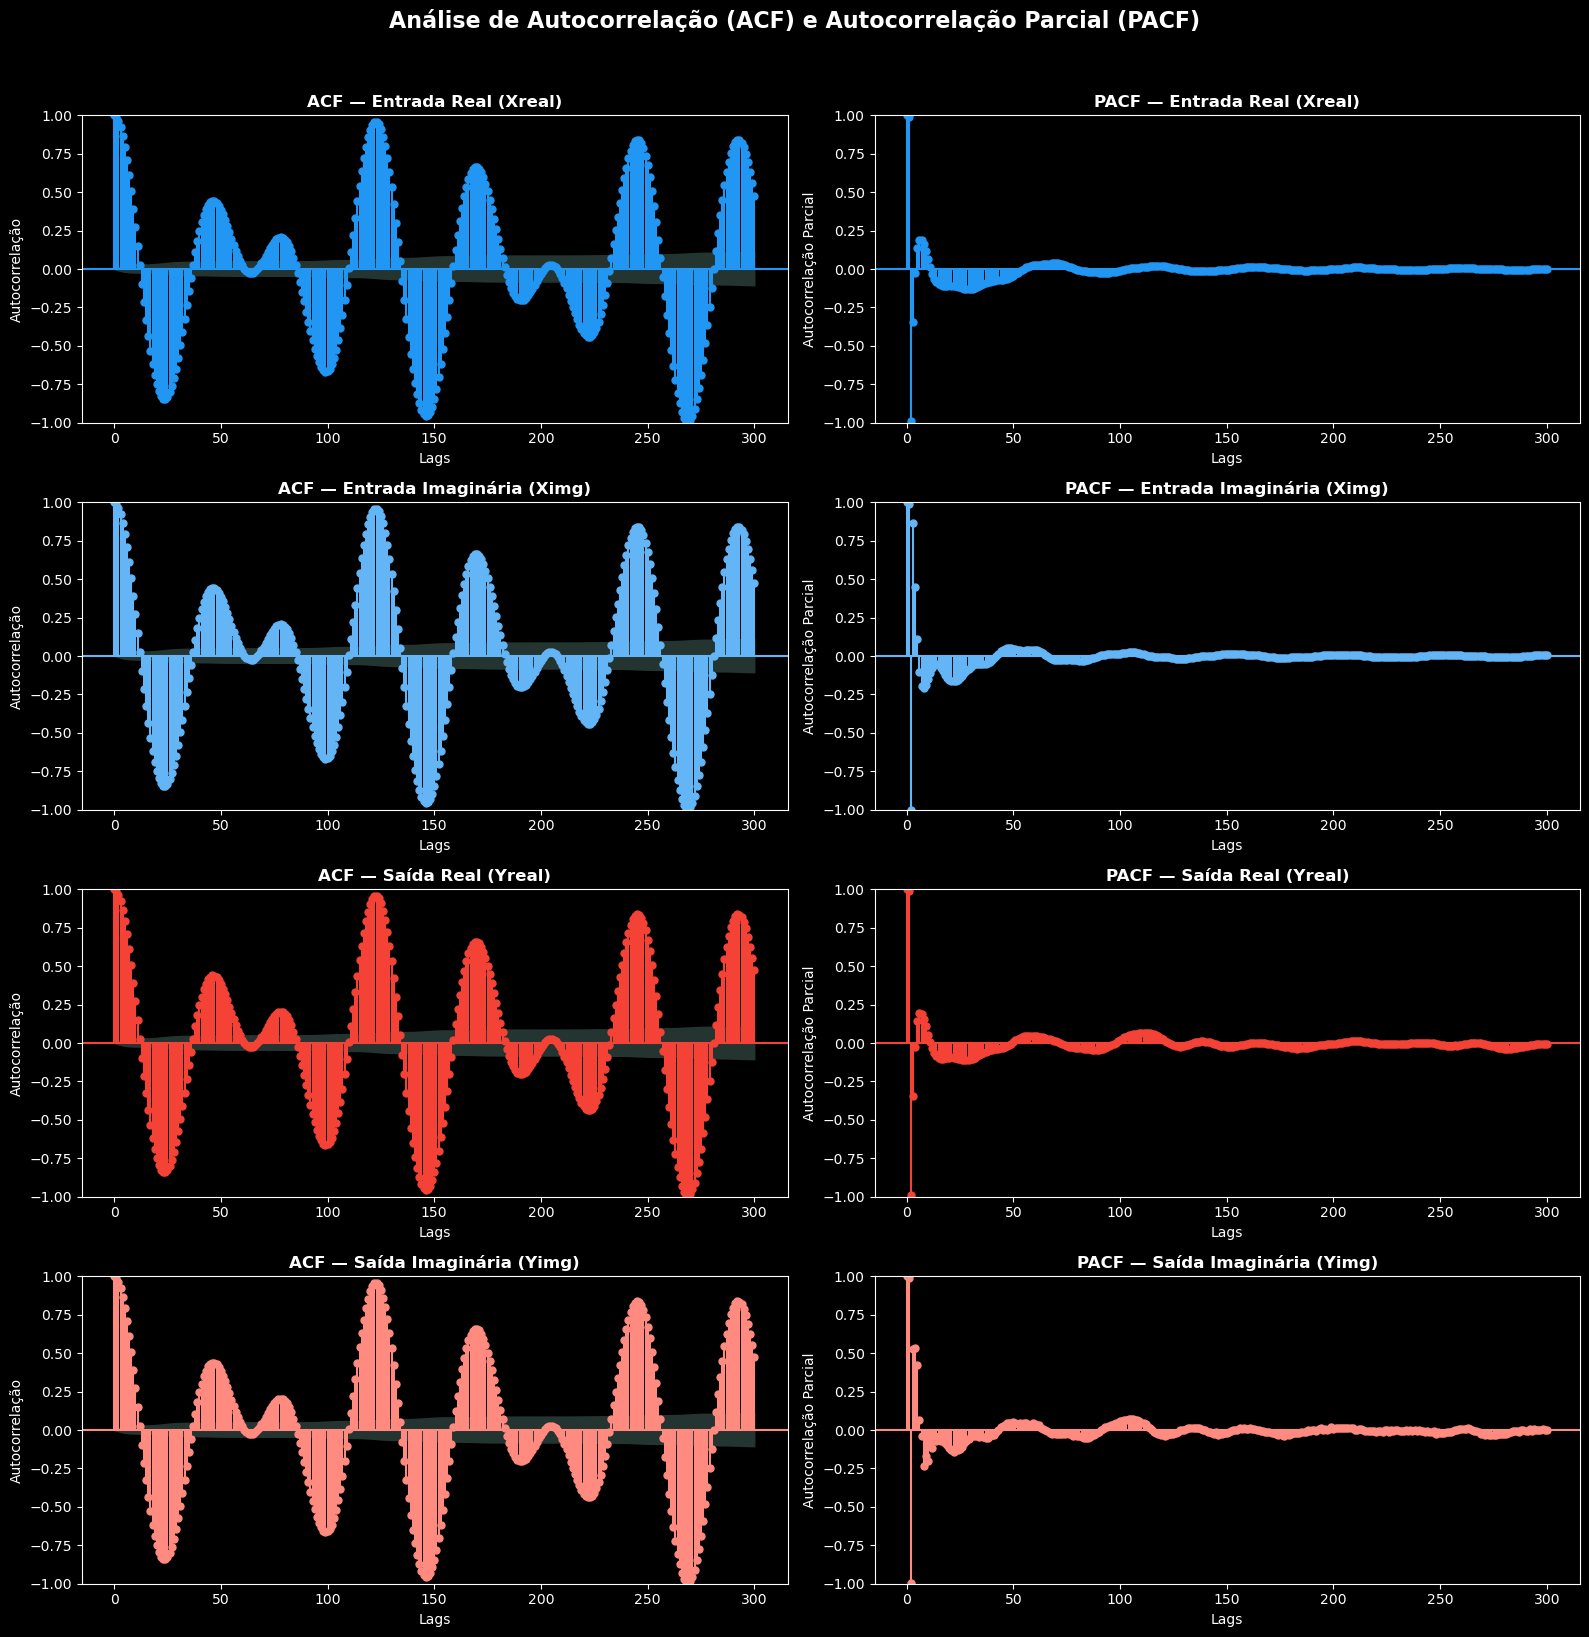

In [23]:
# Plot Lateral
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_acf_pacf(df_input, df_output, lags=300, dark_mode=True, figsize=(16, 16)):
    """
    Plota ACF e PACF para todos os sinais de entrada e saída.
    """

    if dark_mode:
        plt.style.use('dark_background')
        text_color = 'white'
    else:
        plt.style.use('default')
        text_color = 'black'

    config = [
        {"data": df_input["Xreal"],  "nome": "Entrada Real (Xreal)",      "cor": "#2196F3"},
        {"data": df_input["Ximg"],   "nome": "Entrada Imaginária (Ximg)", "cor": "#64B5F6"},
        {"data": df_output["Yreal"], "nome": "Saída Real (Yreal)",        "cor": "#f44336"},
        {"data": df_output["Yimg"],  "nome": "Saída Imaginária (Yimg)",   "cor": "#FF8A80"},
    ]

    fig, axes = plt.subplots(len(config), 2, figsize=figsize)

    for i, cfg in enumerate(config):

        # ACF (coluna esquerda)
        plot_acf(cfg["data"], lags=lags, ax=axes[i, 0],
                 color=cfg["cor"], vlines_kwargs={'color': cfg["cor"]})
        axes[i, 0].set_title(f'ACF — {cfg["nome"]}',
                            fontsize=12, fontweight='bold', color=text_color)
        axes[i, 0].set_xlabel('Lags', color=text_color)
        axes[i, 0].set_ylabel('Autocorrelação', color=text_color)

        # PACF (coluna direita)
        plot_pacf(cfg["data"], lags=lags, ax=axes[i, 1],
                  color=cfg["cor"], vlines_kwargs={'color': cfg["cor"]})
        axes[i, 1].set_title(f'PACF — {cfg["nome"]}',
                            fontsize=12, fontweight='bold', color=text_color)
        axes[i, 1].set_xlabel('Lags', color=text_color)
        axes[i, 1].set_ylabel('Autocorrelação Parcial', color=text_color)

    plt.suptitle('Análise de Autocorrelação (ACF) e Autocorrelação Parcial (PACF)',
                 fontsize=16, fontweight='bold', color=text_color, y=1.02)
    plt.tight_layout()
    plt.show()
    plt.style.use('default')

# Uso:
plot_acf_pacf(df_input, df_output, lags=300)

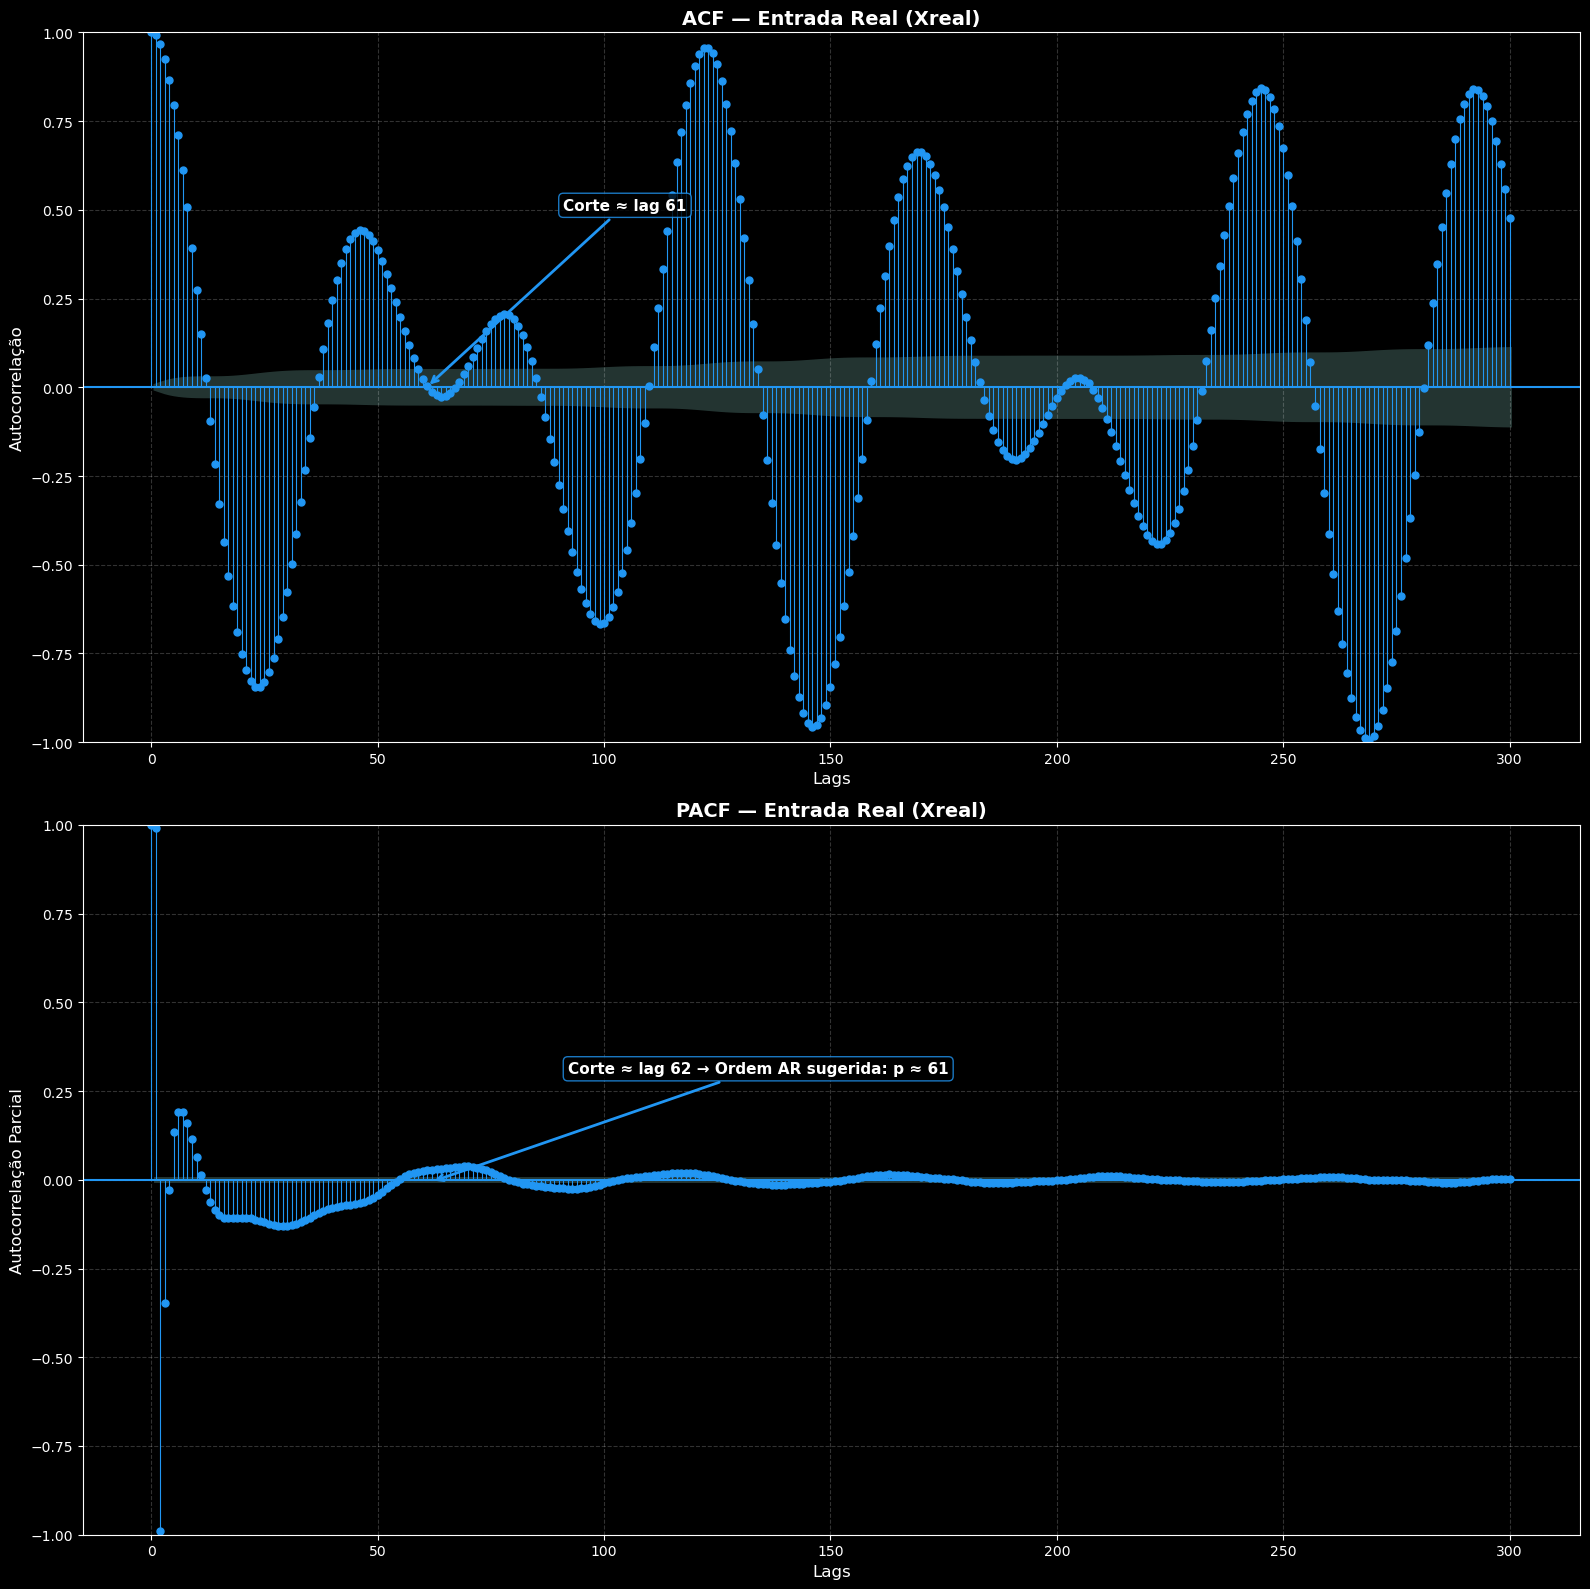

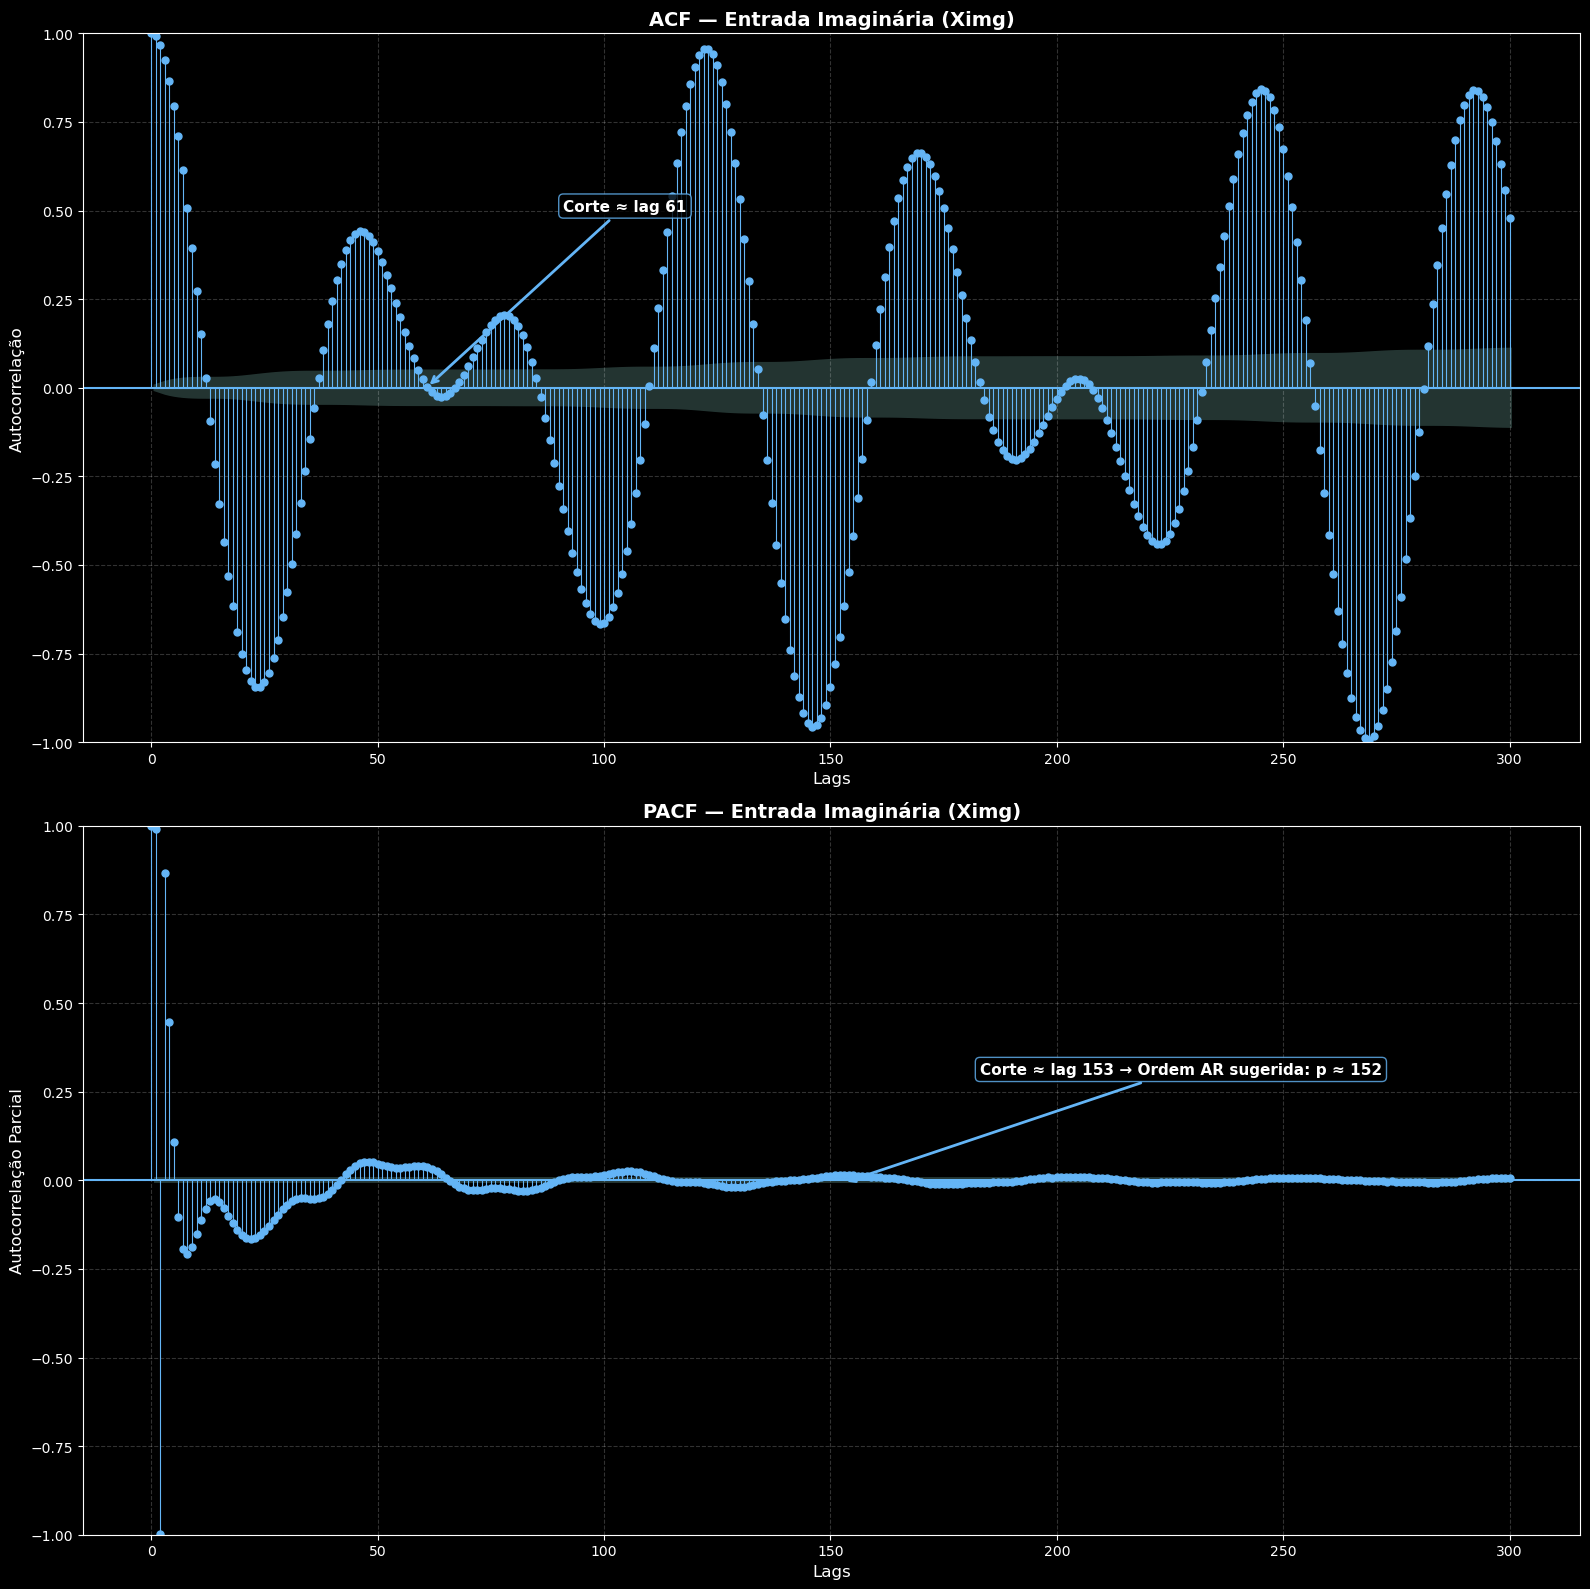

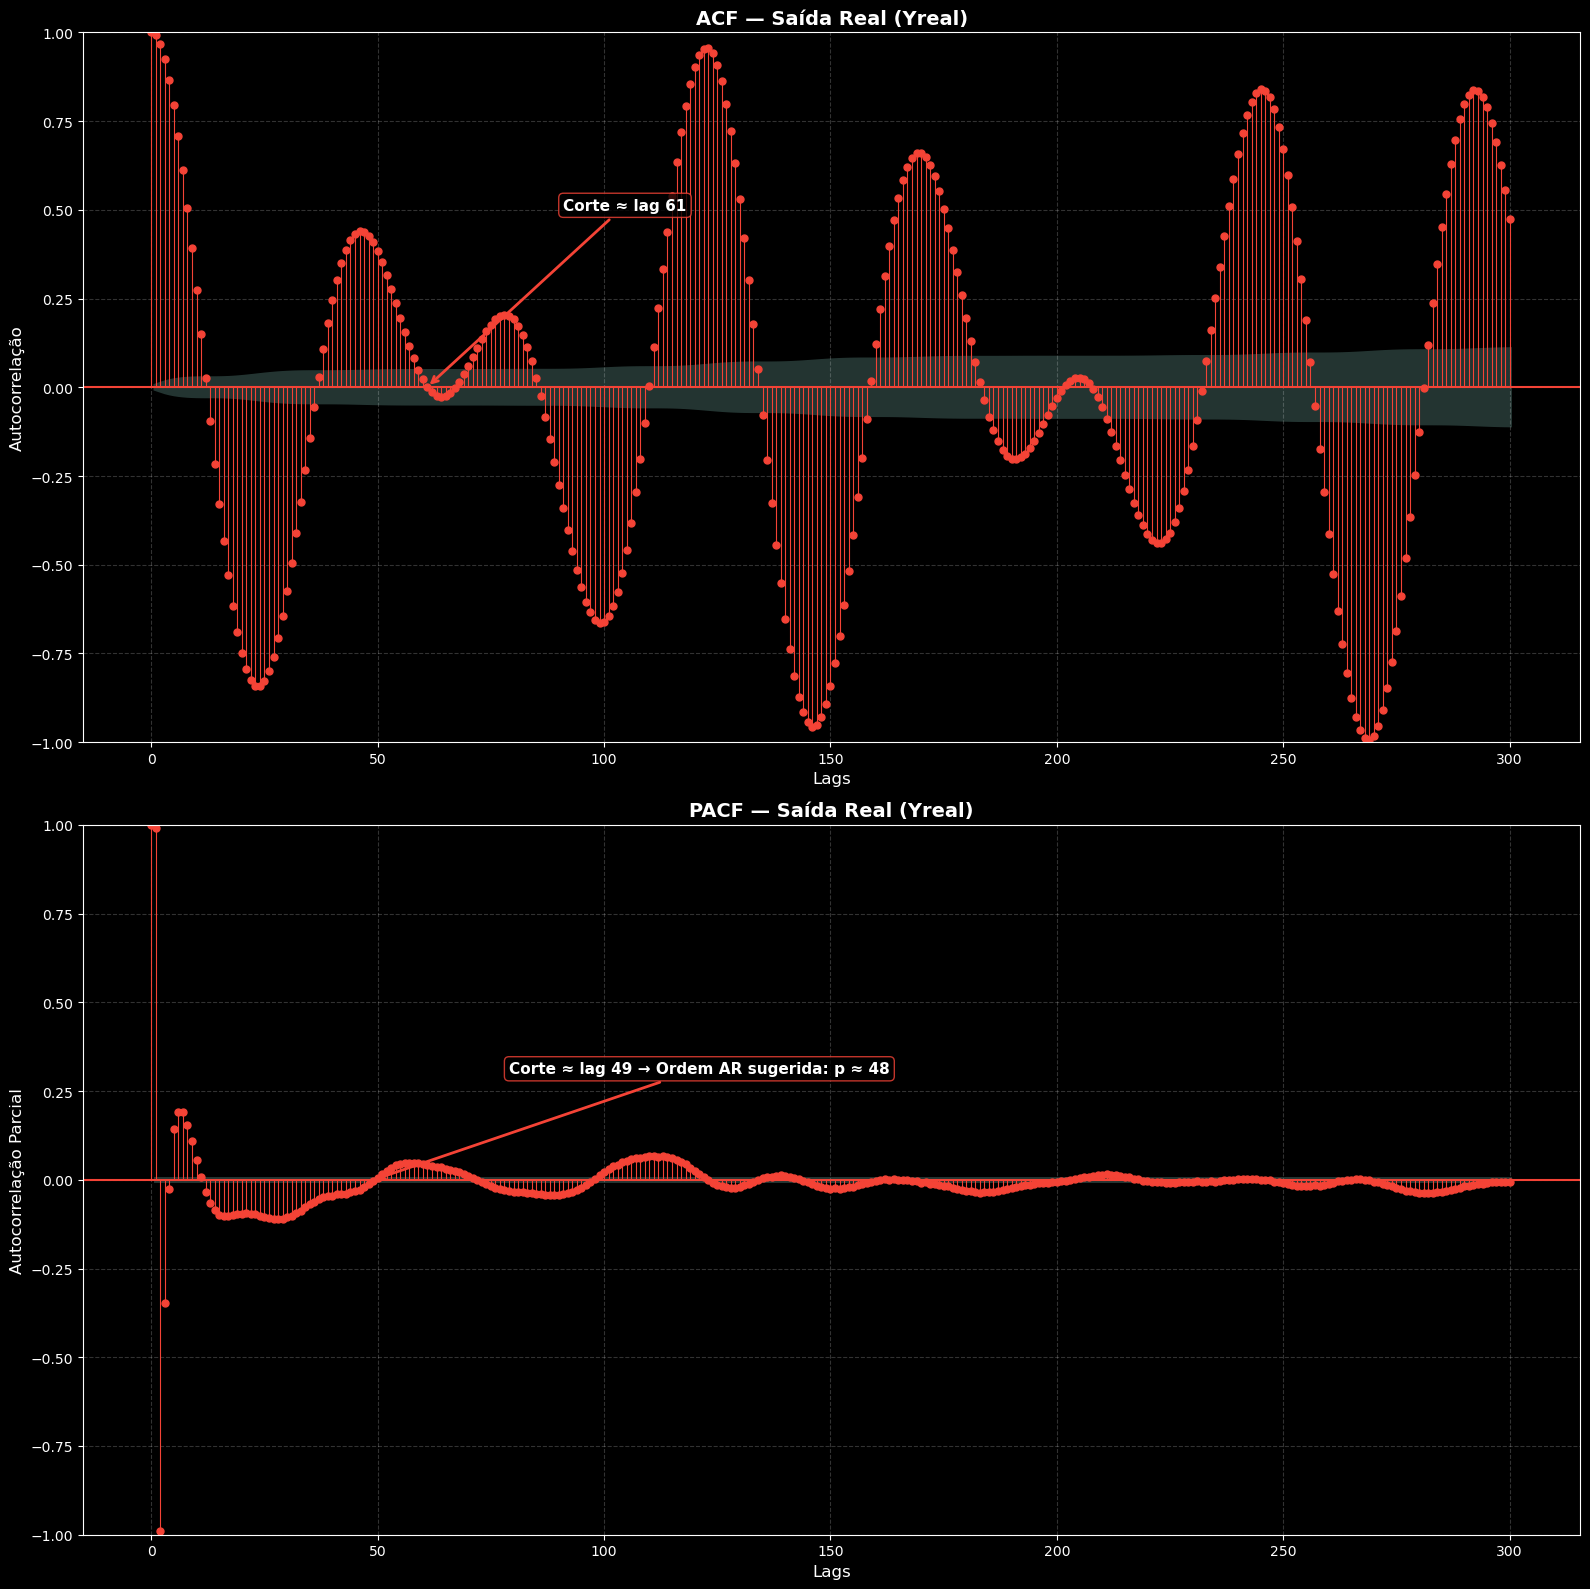

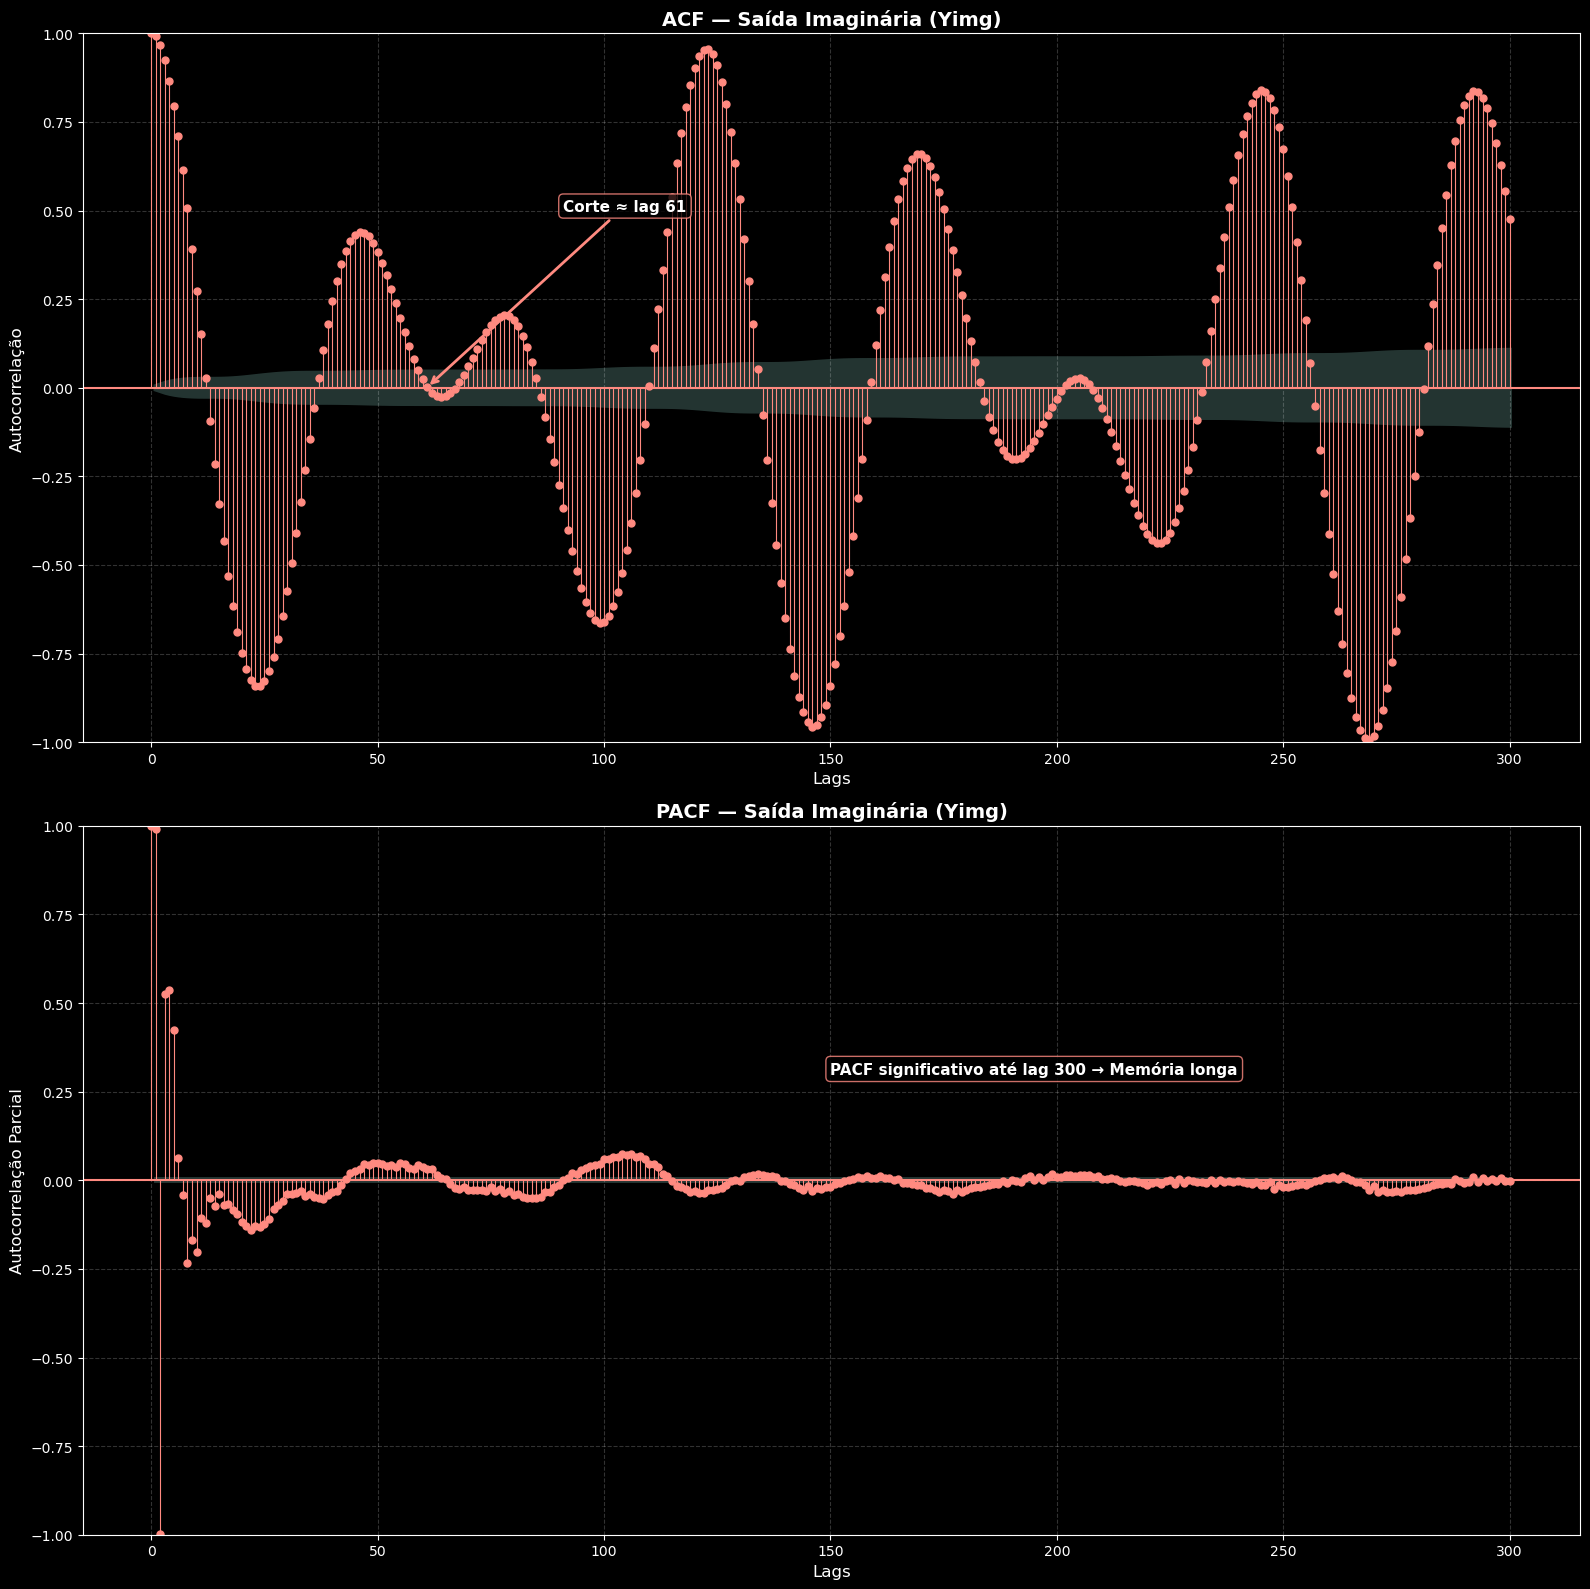

In [27]:
# Plot Individual
def plot_acf_pacf_individual(df_input, df_output, lags=300,
                              dark_mode=True, figsize=(16, 16)):
    """
    Plota ACF e PACF de cada sinal INDIVIDUALMENTE,
    um gráfico abaixo do outro, para análise detalhada.

    Parameters:
    -----------
    df_input   : pd.DataFrame -> DataFrame com 'Xreal' e 'Ximg'
    df_output  : pd.DataFrame -> DataFrame com 'Yreal' e 'Yimg'
    lags       : int          -> Número de lags a analisar
    dark_mode  : bool         -> Ativar fundo preto
    figsize    : tuple        -> Tamanho de CADA par de gráficos (largura, altura)
    """

    if dark_mode:
        plt.style.use('dark_background')
        text_color = 'white'
        ci_color = '#444444'
    else:
        plt.style.use('default')
        text_color = 'black'
        ci_color = '#DDDDDD'

    config = [
        {"data": df_input["Xreal"],  "nome": "Entrada Real (Xreal)",      "cor": "#2196F3"},
        {"data": df_input["Ximg"],   "nome": "Entrada Imaginária (Ximg)", "cor": "#64B5F6"},
        {"data": df_output["Yreal"], "nome": "Saída Real (Yreal)",        "cor": "#f44336"},
        {"data": df_output["Yimg"],  "nome": "Saída Imaginária (Yimg)",   "cor": "#FF8A80"},
    ]

    for cfg in config:

        # ============================================================
        # Criar figura individual para cada sinal
        # ============================================================
        fig, axes = plt.subplots(2, 1, figsize=figsize)

        # ────────────────────────────────────────────
        # ACF (gráfico superior)
        # ────────────────────────────────────────────
        plot_acf(cfg["data"], lags=lags, ax=axes[0],
                 color=cfg["cor"],
                 vlines_kwargs={'color': cfg["cor"], 'linewidth': 0.8},
                 alpha=0.05)  # 95% de confiança

        axes[0].set_title(f'ACF — {cfg["nome"]}',
                         fontsize=14, fontweight='bold', color=text_color)
        axes[0].set_xlabel('Lags', color=text_color, fontsize=12)
        axes[0].set_ylabel('Autocorrelação', color=text_color, fontsize=12)
        axes[0].grid(True, linestyle='--', alpha=0.2)

        # Adicionar anotação do primeiro lag significativo
        _anotar_corte_acf(axes[0], cfg["data"], lags, cfg["cor"], text_color)

        # ────────────────────────────────────────────
        # PACF (gráfico inferior)
        # ────────────────────────────────────────────
        plot_pacf(cfg["data"], lags=lags, ax=axes[1],
                  color=cfg["cor"],
                  vlines_kwargs={'color': cfg["cor"], 'linewidth': 0.8},
                  alpha=0.05)  # 95% de confiança

        axes[1].set_title(f'PACF — {cfg["nome"]}',
                         fontsize=14, fontweight='bold', color=text_color)
        axes[1].set_xlabel('Lags', color=text_color, fontsize=12)
        axes[1].set_ylabel('Autocorrelação Parcial', color=text_color, fontsize=12)
        axes[1].grid(True, linestyle='--', alpha=0.2)

        # Adicionar anotação do primeiro lag de corte
        _anotar_corte_pacf(axes[1], cfg["data"], lags, cfg["cor"], text_color)

        plt.tight_layout()
        plt.show()

    plt.style.use('default')


# ================================================================
# FUNÇÕES AUXILIARES DE ANOTAÇÃO
# ================================================================

def _anotar_corte_acf(ax, serie, lags, cor, text_color):
    """
    Encontra e anota o primeiro lag onde o ACF cai
    dentro do intervalo de confiança.
    """
    from statsmodels.tsa.stattools import acf

    # Calcula ACF
    valores_acf, confint = acf(serie, nlags=lags, alpha=0.05)

    # Limite do intervalo de confiança
    n = len(serie)
    limite = 1.96 / np.sqrt(n)

    # Encontra o primeiro lag onde |ACF| < limite (ignora lag 0)
    lag_corte = None
    for i in range(1, len(valores_acf)):
        if abs(valores_acf[i]) < limite:
            lag_corte = i
            break

    if lag_corte:
        ax.annotate(f'Corte ≈ lag {lag_corte}',
                    xy=(lag_corte, valores_acf[lag_corte]),
                    xytext=(lag_corte + lags*0.1, 0.5),
                    fontsize=11, color=text_color, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=cor, lw=2),
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='black',
                             edgecolor=cor, alpha=0.8))
    else:
        ax.annotate(f'ACF significativo até lag {lags}',
                    xy=(lags*0.5, 0.5),
                    fontsize=11, color=text_color, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='black',
                             edgecolor=cor, alpha=0.8))


def _anotar_corte_pacf(ax, serie, lags, cor, text_color):
    """
    Encontra e anota o primeiro lag onde o PACF cai
    dentro do intervalo de confiança.
    """
    from statsmodels.tsa.stattools import pacf

    # Calcula PACF
    valores_pacf, confint = pacf(serie, nlags=lags, alpha=0.05)

    # Limite do intervalo de confiança
    n = len(serie)
    limite = 1.96 / np.sqrt(n)

    # Encontra o primeiro lag onde |PACF| < limite (ignora lag 0)
    lag_corte = None
    for i in range(1, len(valores_pacf)):
        if abs(valores_pacf[i]) < limite:
            lag_corte = i
            break

    if lag_corte:
        ax.annotate(f'Corte ≈ lag {lag_corte} → Ordem AR sugerida: p ≈ {lag_corte - 1}',
                    xy=(lag_corte, valores_pacf[lag_corte]),
                    xytext=(lag_corte + lags*0.1, 0.3),
                    fontsize=11, color=text_color, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=cor, lw=2),
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='black',
                             edgecolor=cor, alpha=0.8))
    else:
        ax.annotate(f'PACF significativo até lag {lags} → Memória longa',
                    xy=(lags*0.5, 0.3),
                    fontsize=11, color=text_color, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='black',
                             edgecolor=cor, alpha=0.8))

# Plotar todos os sinais individualmente (um abaixo do outro)
plot_acf_pacf_individual(df_input, df_output, lags=300)

#### Análise dos gráficos

    Gráfico ACF:                        Gráfico PACF:

    Correlação                          Correlação
    1.0│█                               1.0│█
       │█                                  │█
       │█                                  │
       │██                                 │
       │ ██                                │
       │  ███                              │
       │    ████                           │
       │       ██████                      │
    ───│─────────────────── IC 95%      ───│─────────────────── IC 95%
    0.0│            ████████████        0.0│  ████████████████████
       │                                   │
    ↑ Decaimento GRADUAL               ↑ Corte ABRUPTO após lag p
    → Indica processo AR                → Indica ORDEM p do modelo AR

#### Para determinar a ordem do modelo

**Regra 1 - Identificar odem AR (p):**

Olhar o PACF: O lag onde o PACF "corta" (cai dentro da faixa de confiança) indica a ordem p

    Ex:
    PACF corta no lag 3 → p = 3
    PACF corta no lag 5 → p = 5

**Regra 2 - Identificar odem MA (q):**

Olhar o ACF: O lag onde o ACF "corta" (cai dentro da faixa de confiança) indica a ordem q

    Ex:
    ACF corta no lag 2 → q = 2
    ACF corta no lag 4 → q = 4

**Regra 3 - Padrões típicos:**

| Modelo | ACF | PACF |
| :--- | :--- | :--- |
| **AR(p)** | Decai gradualmente | Corta no **lag p** |
| **MA(q)** | Corta no **lag q** | Decai gradualmente |
| **ARMA(p,q)** | Decai gradualmente | Decai gradualmente |

#### Devivo a faixa azul (intervalo de Confiança)

    Correlação
       │█
       │█
       │ █
       │  █
    ═══│══════════════════════  ← Limite superior (IC 95%)
    0.0│    ██ █ █  █ █  █ █   ← Lags dentro da faixa = NÃO significativos
    ═══│══════════════════════  ← Limite inferior (IC 95%)
       │
       ┼────────────────────
       0        Lags

    → Barras DENTRO da faixa azul = correlação NÃO significativa
    → Barras FORA da faixa azul = correlação SIGNIFICATIVA
    → A faixa é calculada como ± 1.96/√N (para 95% de confiança)

### Célula 19 - Análise de Correlação Cruzada (CCF)
> A  CCF (Cross-Correlation Function) mede a correlação entre DUAS séries temporais diferentes em função do deslocamento temporal (lag). Diferente da ACF (que compara uma série consigo mesma), a CCF compara a Entrada (X) com a Saída (Y) do PA para identificar o atraso de grupo e a resposta impulsiva do amplificador.

    Correlação Cruzada (CCF)
    ═══════════════════════════════════════════════════

    Mede o quanto o sinal de SAÍDA está correlacionado
    com versões ATRASADAS do sinal de ENTRADA.

    Entrada X(t):    [x₁, x₂, x₃, x₄, x₅, x₆, x₇, x₈]
    Saída   Y(t):    [y₁, y₂, y₃, y₄, y₅, y₆, y₇, y₈]

    CCF calcula:
      lag=0:  corr(X(t),   Y(t))    → Correlação instantânea
      lag=1:  corr(X(t),   Y(t+1))  → X influencia Y 1 amostra depois?
      lag=2:  corr(X(t),   Y(t+2))  → X influencia Y 2 amostras depois?
      lag=-1: corr(X(t),   Y(t-1))  → Y influencia X? (causalidade reversa)
      lag=-2: corr(X(t),   Y(t-2))  → Y influencia X?


    Atraso de Grupo (Group Delay)
    ═══════════════════════════════════════════════════

    É o TEMPO que o sinal leva para "atravessar" o
    amplificador, da entrada até a saída.

    Entrada X(t):
    ──╱╲──────────────────────────────────
      t₀

    Saída Y(t):                    Atraso = k amostras
    ──────────╱╲──────────────────────────
              t₀ + k
              ↑
              Sinal aparece k amostras DEPOIS

    ┌──────────────────────────────────────────────────────────┐
    │                                                          │
    │  No gráfico CCF:                                         │
    │  → O LAG do PICO MÁXIMO = Atraso de Grupo               │
    │                                                          │
    │  Exemplo:                                                │
    │  Se o pico da CCF está no lag 3:                         │
    │  → O PA tem um atraso de 3 amostras                      │
    │  → Y(t) depende mais fortemente de X(t-3)               │
    │  → Isso é CRUCIAL para a modelagem VARMAX               │
    │    (indica que lags de pelo menos 3 são necessários)     │
    │                                                          │
    └──────────────────────────────────────────────────────────┘

| O que buscar | Significado |
| :--- | :--- |
| **Lag do pico** | Atraso de grupo do Amplificador de Potência (PA). |
| **Altura do pico** | Força da correlação entre entrada $\rightarrow$ saída. |
| **Largura do pico** | Dispersão temporal (efeitos de memória do dispositivo). |
| **Simetria** | Causalidade (deve ser tipicamente assimétrico em sistemas reais). |
| **Cross-coupling** | $X_{real} \rightarrow Y_{img}$ deve ser $\approx 0$ (em PAs lineares). |

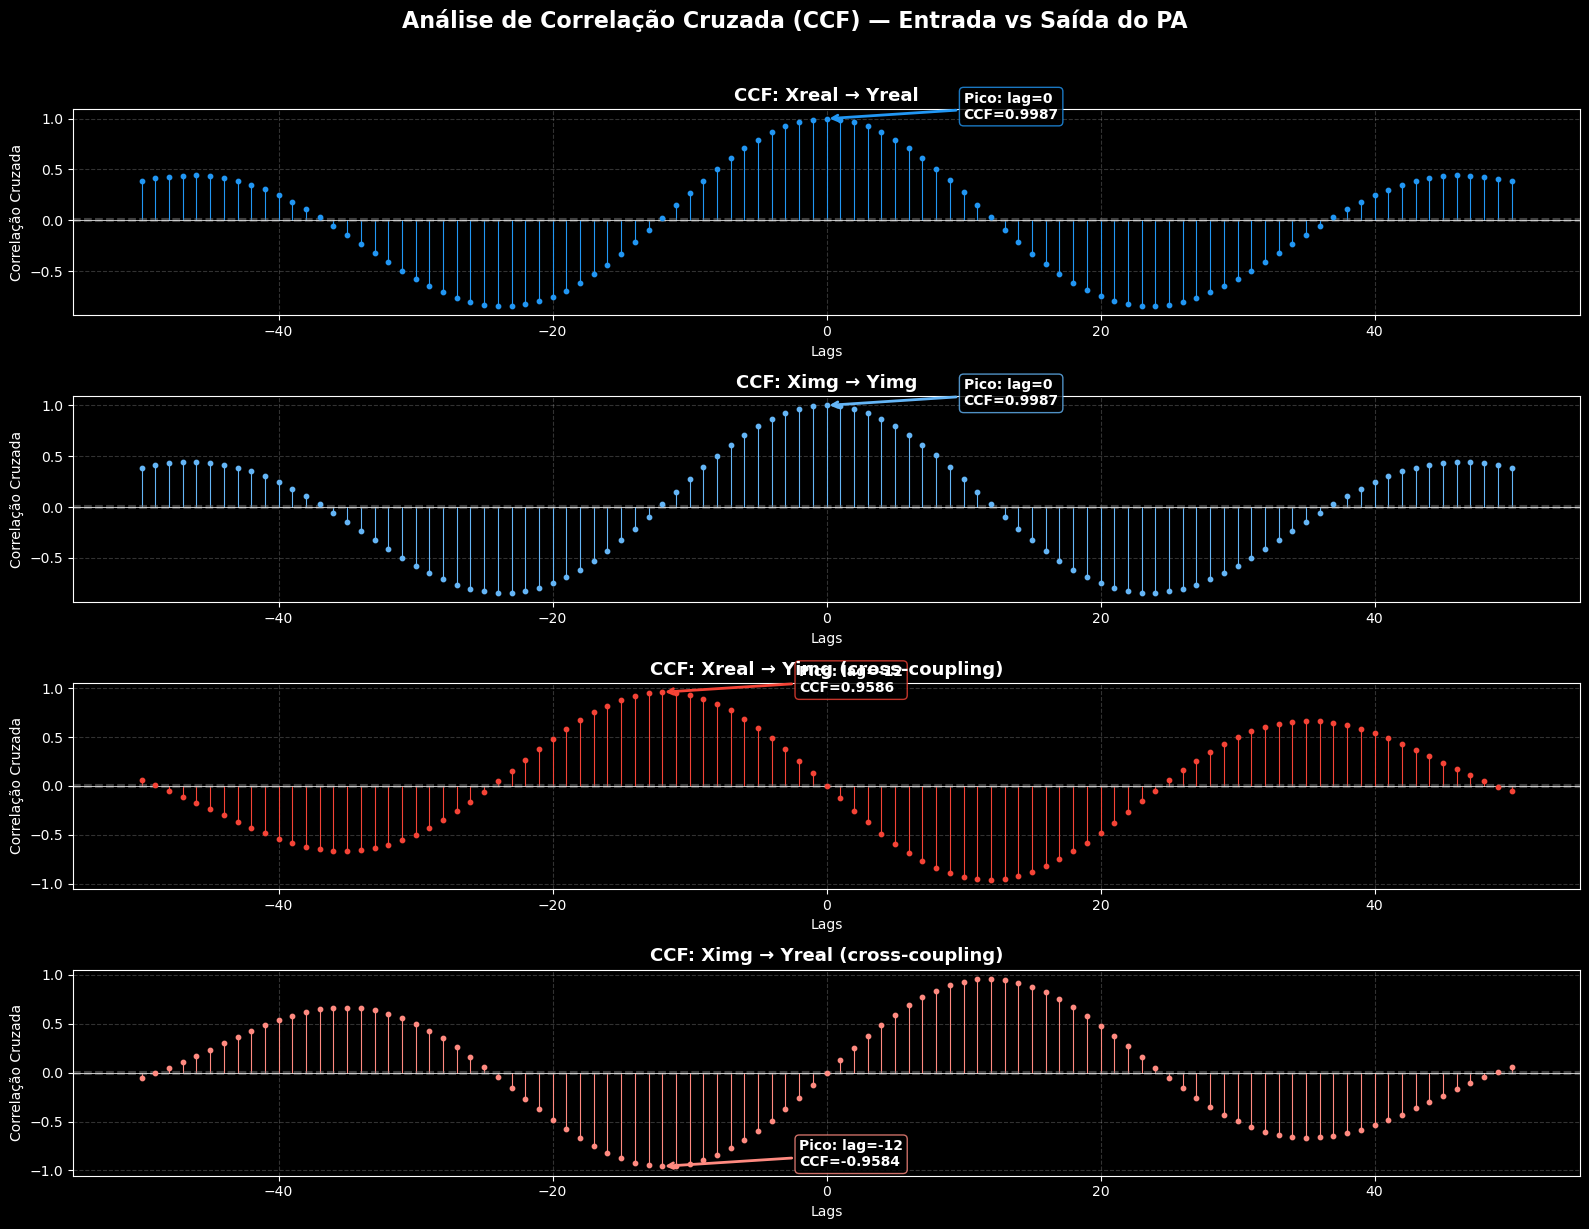

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf

# ================================================================
# 1. PRIMEIRO: Definir a função auxiliar plot_ccf_manual
# ================================================================

def plot_ccf_manual(x, y, lags=50, ax=None, color='#2196F3'):
    """
    Calcula e plota a CCF (Cross-Correlation Function) manualmente.

    Parameters:
    -----------
    x     : pd.Series -> Série de entrada
    y     : pd.Series -> Série de saída
    lags  : int       -> Número de lags
    ax    : matplotlib axis -> Eixo para plotar
    color : str       -> Cor das barras
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(15, 4))

    # Calcular CCF para lags positivos
    ccf_pos = ccf(x, y, adjusted=False)[:lags+1]
    # Calcular CCF para lags negativos
    ccf_neg = ccf(y, x, adjusted=False)[1:lags+1][::-1]

    # Combinar lags negativos e positivos
    ccf_total = np.concatenate([ccf_neg, ccf_pos])
    lag_range = np.arange(-lags, lags+1)

    # Plotar barras verticais
    ax.vlines(lag_range, 0, ccf_total, color=color, linewidth=0.8)
    ax.scatter(lag_range, ccf_total, color=color, s=10, zorder=5)

    # Intervalo de confiança (95%)
    n = len(x)
    limite = 1.96 / np.sqrt(n)
    ax.axhline(y=limite, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=-limite, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=0, color='white', linewidth=0.5)

    # Encontrar e anotar o pico máximo
    idx_pico = np.argmax(np.abs(ccf_total))
    lag_pico = lag_range[idx_pico]
    valor_pico = ccf_total[idx_pico]
    ax.annotate(f'Pico: lag={lag_pico}\nCCF={valor_pico:.4f}',
                xy=(lag_pico, valor_pico),
                xytext=(lag_pico + lags*0.2, valor_pico),
                fontsize=10, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=color, lw=2),
                bbox=dict(boxstyle='round', facecolor='black',
                         edgecolor=color, alpha=0.8),
                color='white')

    ax.set_xlabel('Lags')
    ax.set_ylabel('Correlação Cruzada')
    ax.grid(True, linestyle='--', alpha=0.2)

    return ax


# ================================================================
# 2. DEPOIS: Definir a função principal plot_ccf_completo
# ================================================================

def plot_ccf_completo(df_input, df_output, lags=50,
                       dark_mode=True, figsize=(16, 12)):
    """
    Plota CCF completa entre todos os pares de entrada/saída.

    Parameters:
    -----------
    df_input   : pd.DataFrame -> DataFrame com 'Xreal' e 'Ximg'
    df_output  : pd.DataFrame -> DataFrame com 'Yreal' e 'Yimg'
    lags       : int          -> Número de lags
    dark_mode  : bool         -> Ativar fundo preto
    figsize    : tuple        -> Tamanho da figura
    """

    if dark_mode:
        plt.style.use('dark_background')
        text_color = 'white'
    else:
        plt.style.use('default')
        text_color = 'black'

    config = [
        {"x": df_input["Xreal"], "y": df_output["Yreal"],
         "titulo": "CCF: Xreal → Yreal", "cor": "#2196F3"},
        {"x": df_input["Ximg"],  "y": df_output["Yimg"],
         "titulo": "CCF: Ximg → Yimg",   "cor": "#64B5F6"},
        {"x": df_input["Xreal"], "y": df_output["Yimg"],
         "titulo": "CCF: Xreal → Yimg (cross-coupling)", "cor": "#f44336"},
        {"x": df_input["Ximg"],  "y": df_output["Yreal"],
         "titulo": "CCF: Ximg → Yreal (cross-coupling)", "cor": "#FF8A80"},
    ]

    fig, axes = plt.subplots(4, 1, figsize=figsize)

    for ax, cfg in zip(axes, config):
        # Agora plot_ccf_manual já está definida ✅
        plot_ccf_manual(cfg["x"], cfg["y"], lags=lags,
                       ax=ax, color=cfg["cor"])
        ax.set_title(cfg["titulo"], fontsize=13,
                    fontweight='bold', color=text_color)

    plt.suptitle('Análise de Correlação Cruzada (CCF) — Entrada vs Saída do PA',
                 fontsize=16, fontweight='bold', color=text_color, y=1.02)
    plt.tight_layout()
    plt.show()
    plt.style.use('default')


# ================================================================
# 3. POR ÚLTIMO: Chamar a função
# ================================================================

plot_ccf_completo(df_input, df_output, lags=50)

### Bloco 05 - Modelagem VARMAX
>  VARMAX (*Vector AutoRegressive Moving Average with eXogenous variables*) é um modelo estatístico multivariado para séries temporais que permite modelar múltiplas variáveis de saída simultaneamente, considerando seus valores passados, erros passados e variáveis externas de entrada. No contexto de PA, ele modela a relação entre a entrada (X) e a saída (Y) do amplificador. Bloco principal, onde tudo o que foi diagnosticado torna-se o modelo.

    V-A-R-M-A-X
    ═══════════════════════════════════════════════════

    V   = VECTOR (Vetorial)
        → Modela MÚLTIPLAS variáveis simultaneamente
        → No nosso caso: [Yreal, Yimg] (2 variáveis)

    AR  = AUTO-REGRESSIVE (Autoregressivo)
        → Usa valores PASSADOS da própria saída
        → Y(t) depende de Y(t-1), Y(t-2), ..., Y(t-p)
        → Ordem p = quantos lags do passado usar

    MA  = MOVING AVERAGE (Média Móvel)
        → Usa ERROS PASSADOS do modelo
        → Y(t) depende de ε(t-1), ε(t-2), ..., ε(t-q)
        → Ordem q = quantos erros passados usar

    X   = eXogenous variables (Variáveis Exógenas)
        → Usa variáveis EXTERNAS como entrada
        → No nosso caso: [Xreal, Ximg]
        → O PA recebe X como entrada e produz Y como saída

#### Modelo Vetorial Matricial
$$\begin{bmatrix}
Y_{real}(t) \\
Y_{img}(t)
\end{bmatrix} =
\underbrace{\begin{bmatrix} A_{11} & A_{12} \\ A_{21} & A_{22} \end{bmatrix} \begin{bmatrix} Y_{real}(t-1) \\ Y_{img}(t-1) \end{bmatrix}}_{\text{Parte AR}} +
\underbrace{\begin{bmatrix} B_{11} & B_{12} \\ B_{21} & B_{22} \end{bmatrix} \begin{bmatrix} \varepsilon_{1}(t-1) \\ \varepsilon_{2}(t-1) \end{bmatrix}}_{\text{Parte MA}} +
\underbrace{\begin{bmatrix} C_{11} & C_{12} \\ C_{21} & C_{22} \end{bmatrix} \begin{bmatrix} X_{real}(t) \\ X_{img}(t) \end{bmatrix}}_{\text{Parte Exógena}} +
\underbrace{\begin{bmatrix} \varepsilon_{1}(t) \\ \varepsilon_{2}(t) \end{bmatrix}}_{\text{Erro/Ruído}}$$

#### Forma Simplificada
$$Y(t) = \mathbf{A} Y(t-1) + \mathbf{B} \varepsilon(t-1) + \mathbf{C} X(t) + \varepsilon(t)$$

#### Definições dos Componentes
| Termo | Descrição |
| :--- | :--- |
| **$Y(t)$** | Vetor $[Y_{real}(t), Y_{img}(t)]^T$ $\rightarrow$ **Saída** do PA |
| **$X(t)$** | Vetor $[X_{real}(t), X_{img}(t)]^T$ $\rightarrow$ **Entrada** do PA |
| **$\mathbf{A}$** | Matriz de coeficientes **AR** (passado da saída/memória) |
| **$\mathbf{B}$** | Matriz de coeficientes **MA** (erros passados/suavização) |
| **$\mathbf{C}$** | Matriz de coeficientes **Exógenos** (impacto direto da entrada) |
| **$\varepsilon(t)$** | Vetor de **erros/ruído** no instante atual |
| **$p$** | Ordem **AR** (quantidade de lags de $Y$ utilizados) |
| **$q$** | Ordem **MA** (quantidade de lags de $\varepsilon$ utilizados) |

#### Motivação para modelar o PA com o VARMAX
O PA é um sistema que:
1. Recebe Entrada complexa $\rightarrow X = X_{real} + j\:\cdot X_{img}$
2. Produz saída complex    $\rightarrow Y = Y_{real} + j\:\cdot Y_{img}$
3. Tem Memória             $\rightarrow Y(t) depende de X(t-k)$
4. É Não-Linear            $\rightarrow O Ganho varia com a Potência$

**O VARMAX captura:**
- Múltiplas saídas (Yreal, Yimg)
- Efeitos de memória (via lags AR)
- Influência d entrada (via variáveis exógenas)
- Correlação entre Yreal e Yimg
- Não-Linearidade: Parcialmente (modelo é linear)